In [1]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 에스트라) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "에스트라"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 헤리티지 및 의미 (Heritage & Estuary)
    full_text_part1 = """
    태평양제약에서 시작된 헤리티지에 기반해 오래도록 건강한 아름다움을 선사하는 브랜드
    태평양제약으로 시작된 헤리티지에 기반하여, 오래도록 건강한 아름다움을 선사하는 브랜드, 에스트라
    강과 바다가 만나 이뤄낸 가장 비옥한 땅, 삼각주처럼
    에스트라는 태평양 제약으로부터의 헤리티지와 아모레퍼시픽의 최첨단 피부과학의 만남을 근간으로,
    피부과 전문의들과의 협업을 지속하며 시대에 따라 달라지는 민감피부의 고민해결을 위해
    겉으로 드러난 문제 뿐 아니라 그 근본 원인까지 총체적으로 케어하는 궁극의 피부 솔루션을 제공하며
    건강한 피부를 통해 찾아가는 충만하고 자신감 있는 삶, 오래도록 건강한 아름다움을 선사합니다.
    AESTURA”라는 브랜드명은 영어 단어 “ESTUARY”에서 유래되었으며,
    이는 라틴어 단어 “aestuarium”에서 온 조수의 영향을 받는 해안을 의미합니다.
    강과 바다가 만나 이루어 낸 비옥한 삼각주처럼,
    브랜드는 1982년에 설립된 전신 PACIFIC PHARMA Co.에서 시작된 경험과 연구를 통해
    건강한 아름다움을 구현하고 피부 고민 개선에 기여하는 것을 목표로 합니다.
    """

    # Part 2: 의학적 전문성 및 MD 인증 (Doctors, No.1 & Medical Device)
    full_text_part2 = """
    에스트라가 의사를 만나는 이유
    일시적 윤기와 잠깐의 아름다움이 아닌
    근본적인 피부의 건강과 개선을,
    의사와 함께 고민해나갑니다.
    민감 피부는 학술적으로 정의할 수 있는 질환이 아니라,
    피부에 다양한 불편함을 느끼는 주관적인 느낌이자
    멘탈적인 상태이기 때문에 그래서 에스트라는
    스스로 민감 피부 전문가가 되기로 했습니다.
    오랜 연구 끝에, 민감 피부를 ‘피부 장벽이 약해진 상태’로 정의하고,
    민감 피부의 건조나 노화는 일반 정상 피부와 어떻게 다른지 각종 논문 지식을 섭렵했습니다.
    같은 민감피부라도 저마다 느끼는 문제의 지점이 다릅니다.
    이에 에스트라는 51명의 피부과 전문의와 최신 피부과학의 지견을 나누며
    인사이트를 얻고 끊임없이 연구합니다.
    9년 연속 No.1 한국 병원 화장품 브랜드
    한국소비자브랜드 위원회, 2016-2024
    병원 화장품 부문 올해의 브랜드 대상
    한국 상급종합병원 에스트라 더마 솔루션 채택
    국내 49개 상급종합병원 처방,
    4100여개의 종합병원 의원 입점
    건강심사평가원(HIRA) 수치 기준. 의료기기(MD) 한정.
    메디컬 디바이스(MD) 인증을 받은 이유
    에스트라는 MD 제조 인증을 받는 것이 까다롭고 매우 어려운 과정이라는 것을
    알면서도 늦출 수 없었습니다.
    에스트라는 아토피피부염 환우를 포함하여 보습제 사용이 필수적인
    문제성 피부 환자들의 고민이 얼굴뿐만 아니라 전신으로 발현된다는
    사실을 알게 되었습니다. 피부를 회복하기 위해서는 보습제를 충분히
    사용해야 하는데, 넓은 면적에 사용해야 하는 환자들에게는 상당한
    비용 부담이 따랐습니다.
    아토피 피부염 등 피부 장벽이 손상된 피부의 솔루션을 위해
    MD는 의료기기를 뜻하는 메디컬 디바이스(Medical Device)의 약자입니다.
    MD 제품은 일반 화장품 회사에서는 생산할 수 없습니다.
    식약처로 부터 의료기기 제조업 허가를 획득해야 하고,
    의료기기 제조에 준하는 엄격한 제조 공정과 품질 검수 등
    일정한 기준과 절차에 부합해야 합니다.
    신청 후 인증을 받는 데까지 수년이 걸리는 일이기도 합니다.
    에스트라는 MD 제조 인증을 받는 일이 매우 까다롭고
    어려운 과정임을 알면서도 늦출 수 없었습니다.
    2018년 아토베리어 라인에 이어
    2022년 더마베이비 프로 라인에 MD 인증을 받았습니다.
    """

    # Part 3: 유통 확장 및 365 라인 (Retail Expansion & Product Lines)
    full_text_part3 = """
    병원 밖으로 나온 더마 with 올리브영
    에스트라는 병원 채널을 유지하며
    ‘시판’이라는 새로운 도전에 나서게 됩니다.
    2016년 에스트라는 유수의 해외 더모코스메틱 브랜드들을 제치고
    ‘ 올해의 브랜드’ 병원화장품 부문 대상을 차지했습니다.
    2017년에는 특별한 바이럴 활동을 하지 않았음에도
    아토베리어 크림이 순수하게 병원 방문 고객의 후기만으로
    ‘화해 뷰티 어워드’ 크림·젤 부문 1위에 올랐습니다.
    병원화장품은 병원에서만 살 수 있다 보니 병원에 간 김에 화장품을 살 수는 있지만,
    화장품을 사러 일부러 병원에 가기는 쉽지 않다는 이야기였습니다.
    이미 에스트라는 아토베리어 MD 라인 출시 과정에서 더 많은 고객의
    피부고민을 해결하고자 문제성 피부에서 민감성 피부로
    솔루션 폭을 확대하기로 했던 터였습니다.
    고객과의 접점을 확장해야 한다는 결론에 이르게 했습니다.
    ‘이제 병원 밖 일상에서도 고객을 만나자’
    에스트라는 병원 판매 채널을 유지하며
    ‘시판’이라는 새로운 도전에 나섰습니다.
    시판에 앞서 에스트라는 문제성 피부고민에 맞추어
    병원에서 유통하던 아토베리어(보습),
    테라크네(트러블), 리제덤(자생력 강화) 등
    세 라인을 민감성 피부에 맞게 다시 연구하고 개발해
    시판용 라인을 완성했습니다.
    시판용 라인에는 ‘데일리 더마솔루션’이라는 의미를 더해
    라인명 뒤에 365를 붙였습니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

c:\STUDY-DATA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu
c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


>>> 초기화 완료! 분석을 시작합니다.


📂 새 파일 'total_brand_analysis.csv'을 생성하고 '에스트라' 데이터를 저장했습니다.
    브랜드      구분                              내용 요약                 핵심 키워드  \
0  에스트라  Part 1  태평양제약에서 시작된 헤리티지에 기반해 오래도록 건강한...  아름다움, 건강, 태평양, 제약, 시작   
1  에스트라  Part 2  에스트라가 의사를 만나는 이유     일시적 윤기와 잠...     피부, 인증, 에스, 의료, 기기   
2  에스트라  Part 3  병원 밖으로 나온 더마 with 올리브영     에스트...    병원, 시판, 고객, 라인, 화장품   

    AI 분석 톤   확신도  형용사 수  
0  의학적/전문적인  0.32      1  
1  의학적/전문적인  0.42     15  
2  도전적/혁신적인  0.50      7  


In [2]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: AP) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "AP"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학 (Beauty Beyond & Innovation)
    full_text_part1 = """
    $APEX OF SKINCARE TO UNVEIL BEAUTY BEYOND
    아름다움의 경지를 여는 스킨케어의 정점
    타고난 피부의 한계는 아무리 노력해도 뛰어넘을 수 없을까요?
    AP의 여정은 오랜 통념에 대한 도전에서 시작되었습니다.
    우리는 아름다움에는 한계가 없다는 믿음으로, 그동안 해결하지 못했던 피부 문제와 고민에 대해
    완전히 새로운 차원의 결과를 제공하는 혁신적인 고성능 스킨케어 솔루션을 선보입니다.
    한계를 뛰어넘는 혁신, 아름다움의 새로운 경지를 여는 스킨케어의 정점, AP
    """

    # Part 2: 핵심 기술 및 검증 (Skin Science & Clinical Test)
    full_text_part2 = """
    APEX OF SKINCARE
    새로운 차원의 피부 과학 기술
    화장품 영역에 국한되지 않는 폭넓은 연구와
    글로벌 전문 기관과의 협력을 통해 피부 과학의 혁신을 선도합니다.
    독자 특허 성분
    아주 작고 정밀한 단위에서부터
    연구하여 탄생시킨 독자 성분들은
    한계를 뛰어넘는 압도적 효능과 피부 변화를 제공합니다.
    결과를 검증하는 클리니컬 테스트
    쌍둥이 대상, 특수 케어 영감 인체적용시험 등 선도적인 테스트 방식은
    고성능 안티에이징 효능과 새로운 차원의 피부 결과를 검증합니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 'AP' 데이터를 추가했습니다.
  브랜드      구분                              내용 요약                  핵심 키워드  \
0  AP  Part 1  $APEX OF SKINCARE TO UNVEIL BE...  스킨케어, 한계, 경지, 정점, 아름다움   
1  AP  Part 2  APEX OF SKINCARE     새로운 차원의 피...      피부, 과학, 연구, 선도, 독자   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  1.00      5  
1  도전적/혁신적인  0.96      4  


In [3]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 아윤채) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "아윤채"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학 (Detailed & High Performing)
    full_text_part1 = """
    Detailed & High Performing Salon Care
    아윤채는 디자이너와 고객을 생각합니다.
    디자이너의 불편과 고충, 현실적인 헤어 고민들을 해결하기 위해 끊임없이 연구해온 아윤채의 새로운 접근은 그 답이 될 것입니다. 눈에 보이는 화려함보다 본질에 충실한 기능들을 담백하게 담아내며, 환경과 공존하며 나아가는 아윤채의 철학을 심미적으로 구현했습니다.
    """

    # Part 2: 제품 라인업 (PRO & TAKE HOME)
    full_text_part2 = """
    디자이너 살롱 워크를 위한 PRO와 데일리 헤어 라이프를 위한 TAKE HOME 두 라인업은 제품 구성과 효능, 사용감, 감각적인 향까지 그 무엇도 소홀하지 않은 프로페셔널 헤어 솔루션 브랜드, 아윤채를 온전히 경험할 수 있는 기회가 될 것입니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '아윤채' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약                 핵심 키워드  \
0  아윤채  Part 1  Detailed & High Performing Sal...  아윤채, 디자이너, 고객, 생각, 불편   
1  아윤채  Part 2  디자이너 살롱 워크를 위한 PRO와 데일리 헤어 라이프...   헤어, 살롱, 워크, 데일리, 라이프   

    AI 분석 톤   확신도  형용사 수  
0  감성적/부드러운  0.54      1  
1  감성적/부드러운  0.56      1  


In [4]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 비레디) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "비레디"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 슬로건 및 정의 (Ordinary, but extraordinary)
    full_text_part1 = """
    Ordinary, but extraordinary
    친근하지만 남다른 취향이 있는, 자유롭고 센스 있지만 과하진 않게.
    비레디는 자신의 개성을 자유롭게 표현하고 싶은 남자들을 위한 토탈 스타일링 브랜드입니다.
    """

    # Part 2: 핵심 가치 및 타겟 (Seoul Kids)
    full_text_part2 = """
    더 세련된 방식으로 나를 표현하도록 도와주는
    각자의 개성과 다양성을 존중하고 포용하는
    스타일링에 필요한 모든 것을 제공하는
    토탈 스타일링 브랜드 입니다
    SEOUL KIDS ORDINARY,
    BUT EXTRAORDINARY
    편안하고 유쾌한 친구 같지만 자신만의 색채가 명확하고
    당당하게 자신의 취향을 표현하는
    SEOUL KIDS들을 위해 만들어진 비레디는,
    반복되는 평범한 일상 속에서도
    항상 내 최고의 모습을 찾을 수 있게
    고객들의 옆에서 귀를 기울이며 함께 성장해 나가고 있습니다.
    """

    # Part 3: 브랜드 미션 (Styling Guide)
    full_text_part3 = """
    중요한 순간에 준비된 나를 만들어주는
    나의 스타일, 나의 무드, 나의 톤을 찾아주는
    스타일링의 지향점을 제시하는
    B.READY
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '비레디' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약                핵심 키워드  \
0  비레디  Part 1  Ordinary, but extraordinary   ...    자유, 센스, 남자, 취향, 레디   
1  비레디  Part 2  더 세련된 방식으로 나를 표현하도록 도와주는     각...  자신, 표현, 스타일링, 세련, 방식   
2  비레디  Part 3  중요한 순간에 준비된 나를 만들어주는     나의 스타...   중요, 순간, 준비, 스타일, 무드   

     AI 분석 톤   확신도  형용사 수  
0   감성적/부드러운  0.89      4  
1   감성적/부드러운  0.88      2  
2  신뢰감/진정성있는  0.67      0  


In [5]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 코스알엑스) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "코스알엑스"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학 (Cosmetics + Rx)
    full_text_part1 = """
    오직 성분으로, 오직 코스알엑스
    "Cosmetics(화장품) + Rx(처방) = COSRX"
    코스알엑스는 피부 타입과 관련된 문제를 넘어 우리의 일상이 더욱 아름다워질 수 있도록 하는 것이 무엇인지를 고민해왔습니다.
    화장품이 가져야 할 본질을 들여다보고 아름다움 본연의 가치를 담은 제품을 통해 소비자분들을 만나고 있습니다.
    연구 기반 최적의 성분 배합으로 전 세계 소비자의 피부 문제와 고민은 덜어내고, 진심과 안심을 더하기 위해 노력합니다.
    """

    # Part 2: 브랜드 페르소나 (Mr. Rx)
    full_text_part2 = """
    미스터 알엑스는 오랜시간 동안 일상 속 뷰티 라이프 스타일을 면밀히 바라보고, 피부타입과 관련된 문제를 넘어 우리의 일상이
    더욱 아름다워질 수 있도록 하는 것이 무엇인 지를 고민해왔습니다. 또한 뷰티 산업에서의 다년간의 노하우와 경험을 바탕으로
    코스알엑스라는 이름으로 소비자들을 만나오고 있습니다. 미스터 알엑스는 우리 모두를 대변하며 코스알엑스의 상징으로서
    많은 사람들이 본연의 아름다움을 찾길 바라는 마음으로 정성을 다하고 있습니다.
    """

    # Part 3: 브랜드 컨셉 및 키워드 (Soft Skin Care & Solution)
    full_text_part3 = """
    brand concept Soft Skin Care
    ayered for (sensitive) skin/] Fashion / Fabric - Feeling
    [/texture & tactile sense/
    T.P.O / R(X) = Solution
    (layered a edit a tailor-made/]
    민감피부를위한저자극스킨케어
    피부친화적/저자극/부드러운텍스처
    라이프스타일/일상/공감
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '코스알엑스' 데이터를 추가했습니다.
     브랜드      구분                              내용 요약                핵심 키워드  \
0  코스알엑스  Part 1  오직 성분으로, 오직 코스알엑스     "Cosmeti...    성분, 화장품, 코스, 알, 엑스   
1  코스알엑스  Part 2  미스터 알엑스는 오랜시간 동안 일상 속 뷰티 라이프 스...    알, 엑스, 미스터, 뷰티, 코스   
2  코스알엑스  Part 3  brand concept Soft Skin Care  ...  자극, 피부, 민감, 스킨케어, 친화   

     AI 분석 톤   확신도  형용사 수  
0  신뢰감/진정성있는  0.77      3  
1   감성적/부드러운  0.56      4  
2   감성적/부드러운  0.96      1  


In [6]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 에스쁘아) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "에스쁘아"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 (Makeup Creator)
    full_text_part1 = """
    자신만의 룩을 찾을 수 있도록 영감을 주는 Makeup Creation Brand, espoir
    “Makeup Creator”
    에스쁘아는 독보적이고 생동감 있는 메이크업으로 기대하게 만드는 프리미엄 메이크업 전문 브랜드입니다.
    """

    # Part 2: 전문성 및 기준 (Detailed by Professionals)
    full_text_part2 = """
    Detailed by Professionals
    에스쁘아는 정교한 컬러 쉐이드,
    디테일이 다른 전문성을 크리에이션하는
    K-메이크업 스탠다드 브랜드입니다.
    Espoir is a K-Makeup standard brand
    that creates sophisticated color shades
    and professionalism with
    different details.
    """

    # Part 3: 브랜드 슬로건 (Beauty Created by Details)
    full_text_part3 = """
    BEAUTY CREATED
    BY DETAILS.
    ELEVATED SHADES.
    DETAILED BY
    PROFESSIONALS.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '에스쁘아' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약                핵심 키워드  \
0  에스쁘아  Part 1  자신만의 룩을 찾을 수 있도록 영감을 주는 Makeup...    메이크업, 자신, 룩, 수, 영감   
1  에스쁘아  Part 2  Detailed by Professionals     ...  컬러, 쉐이드, 디테일, 크리, 에이   
2  에스쁘아  Part 3  BEAUTY CREATED     BY DETAILS....                         

     AI 분석 톤   확신도  형용사 수  
0   도전적/혁신적인  0.80      1  
1   도전적/혁신적인  0.48      0  
2  신뢰감/진정성있는  0.55      0  


In [7]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 에뛰드) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "에뛰드"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 비전 (Makeup Playlist & Culture)
    full_text_part1 = """
    Make Your Makeup Playlist! ETUDE!
    에뛰드는 즐거운 화장놀이 문화를 전파하는 대한민국 대표 메이크업 브랜드입니다.
    설레는 첫 메이크업의 순간을 함께하는 에뛰드는 메이크업이 더욱 쉽고 즐거운 경험이 되도록 최고의 제품과 서비스를 제공합니다. 다채로운 컬러, 사랑스러운 디자인을 통해 나만의 개성을 찾고, 아름다움을 발견하도록 도와줍니다.
    에뛰드는 화장놀이 문화를 전파하기 위해 에뛰드만의 메이크업 하우투를 생산하고, 경험을 확장합니다. SNS를 활용하여 다양한 미용법을 제공함은 물론, 뷰티 인플루언서가 되고 싶어하는 고객들을 대상으로 유튜버의 꿈을 이루어주는 '뷰티즌' 프로그램을 진행하고 있습니다. 이를 통해 뷰티를 통한 긍정적인 경험과 영향력을 발휘하고, 전 세계를 아우르는 즐거운 메이크업 문화를 만들어나갈 것입니다.
    """

    # Part 2: 브랜드 기원 및 가치 (Origin & Values)
    full_text_part2 = """
    color 라이프 스타일의 다채로움
    Pink 유니크한 핑크
    Princess 멋있고 자신감 있는 주인공
    Makeup Playlist
    나만의 스타일을 찾는 즐거운 화장놀이 문화
    ETUDE Comes from
    ‘ETUDE ’는 쇼팽이 작곡한 아름다운 연습곡의 이름에서 영감을 받아 탄생했어요.
    연습곡이 예술적인 멜로디로 변화하듯
    자신만의 아름다움을 찾아 변화할 수 있도록
    ETUDE는 신나고 설레는 메이크업의 모든 순간을
    함께 하고 싶다는 뜻을 담고 있어요.
    우리는 ETUDE 안에서 다양하고 생동감 넘치는 경험으로
    더 특별한 나를 표현할 수 있다고 믿어요!
    Since 1985
    1985년 12월 창립에서 시작된
    오랫동안 많은 분들의 사랑과 인정을 받아온 에뛰드 스테디셀러
    """

    # Part 3: 스테디셀러 제품 (Loved Products)
    full_text_part3 = """
    Loved Products
    자타공인, 역대 가장 많은 사랑을 받은,
    고민과 검증 끝에 출시된 제품을 만나보세요!
    Fixing Tint
    픽싱 틴트
    네이버 뷰티 윈도우 메이크업 10주 연속 1위
    *2021.11.09 기준
    2021년 글로우픽 어워드 위너 틴트 부문
    #안묻픽싱 #안묻틴트
    Curl Fix Mascara
    컬 픽스 마스카라
    글로우픽 10주 연속 1위컬링 마스카라 부문
    *2021.09.01 기준
    컬링 마스카라 5년 연속 1위 *칸타패널제공
    한국 색조 화장품 시장 내 컬링 마스카라 유형 2015.06.15~2020.06.14 구매량 기준 브랜드 랭킹
    국민BM 400명 검증 완료
    Moistful Collagen
    수분가득 콜라겐
    찐후기가 말해주는 믿고 쓰는 수분 크림
    수분감 만족도 98% *화해 200인 평가단
    보습력 만족도 97% *화해 200인 평가단
    Dear Darling Tint
    디어 달링 틴트
    오랜 시간 사랑받아온 #장수템 #애정템
    촉촉하고 선명하게 물드는 #워터젤 틴트
    2017년 아이스크림 틴트 #대란템
    Fixing Tint
    픽싱 틴트
    네이버 뷰티 윈도우 메이크업 10주 연속 1위
    *2021.11.09 기준
    2021년 글로우픽 어워드 위너 틴트 부문
    #안묻픽싱 #안묻틴트
    Curl Fix Mascara
    컬 픽스 마스카라
    글로우픽 10주 연속 1위컬링 마스카라 부문
    *2021.09.01 기준
    컬링 마스카라 5년 연속 1위 *칸타패널제공
    한국 색조 화장품 시장 내 컬링 마스카라 유형 2015.06.15~2020.06.14 구매량 기준 브랜드 랭킹
    국민BM 400명 검증 완료
    Moistful Collagen
    수분가득 콜라겐
    찐후기가 말해주는 믿고 쓰는 수분 크림
    수분감 만족도 98% *화해 200인 평가단
    보습력 만족도 97% *화해 200인 평가단
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '에뛰드' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약                 핵심 키워드  \
0  에뛰드  Part 1  Make Your Makeup Playlist! ETU...  메이크업, 에뛰드, 문화, 경험, 전파   
1  에뛰드  Part 2  color 라이프 스타일의 다채로움     Pink 유...   스타일, 연습곡, 변화, 수, 라이프   
2  에뛰드  Part 3  Loved Products     자타공인, 역대 가장...    마스카라, 연속, 위, 기준, 컬링   

     AI 분석 톤   확신도  형용사 수  
0   도전적/혁신적인  0.43      5  
1  신뢰감/진정성있는  0.58      7  
2  신뢰감/진정성있는  0.95      1  


In [8]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 젠티스트) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "젠티스트"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 및 의미 (Identity & Meaning)
    full_text_part1 = """
    구강 고민에 독창적인 솔루션을 제공하는 덴탈케어 브랜드, GENTIST
    평범함에서 벗어나 항상 새로운 도전을 하는 ‘Genius Denti-lab’의 의미를 담은 GENTIST는
    """

    # Part 2: 전문성 및 솔루션 (Expertise & Solution)
    full_text_part2 = """
    아모레퍼시픽의 전문적이고 체계적인 41년 구강 연구 노하우를 담아 구강 건강을 위한 새롭고 확실한 솔루션을 제공합니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '젠티스트' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약                 핵심 키워드  \
0  젠티스트  Part 1  구강 고민에 독창적인 솔루션을 제공하는 덴탈케어 브랜드...       고민, 독창, 데, 탈, 케어   
1  젠티스트  Part 2  아모레퍼시픽의 전문적이고 체계적인 41년 구강 연구 노...  구강, 아모레퍼시픽, 전문, 체계, 년   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.99      1  
1  의학적/전문적인  0.94      1  


In [9]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 한율) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "한율"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학 (K-Glass Skin & Balance)
    full_text_part1 = """
    나만의 건강한 균형
    Everyday glass skin, the K-beauty Recipe
    한율은 피부가 건강하게 빛나는 한국 여성의 스킨케어 비법을 전파하는 브랜드 입니다.
    매일 꾸준히 피부와 마음의 ‘비움’과 ‘채움’ 균형을 찾아 관리한 것이 본연의 피부 그 자체로 좋아보이는 한국 여성의 ‘K-glass Skin’의 비결이라고 한율은 생각합니다.
    혹독한 사계절의 변화를 견디며 생명력을 유지하는 한국 자연 원료의 응축된 힘을 피부에 순하지만 강력하게 전하는 동시에, 한국 발효 식품에서 찾아낸 성분을 마이크로바이옴 기술로 개발한 포스트바이오틱스 ‘Skin Balancer™’를 모든 제품에 담아 피부 즉각 개선은 물론 피부 건강을 위한 근본적 솔루션을 제공합니다.
    피부와 마음을 온전히 비우고 충분 채워 나만의 건강한 균형을 찾아주는 한율의 비움채움 루틴은 본질적으로 건강한 피부와 나의 본연의 빛이 드러나게 합니다.
    """

    # Part 2: 핵심 원료 및 헤리티지 (Local Ingredients & Heritage)
    full_text_part2 = """
    한국의 이로움으로 전하는 균형 잡힌 아름다움, 한율
    근본을 관리하는 건강한 피부와 생활 태도로
    균형 잡힌 아름다움을 전하는 K-heritage 클린 기능성 브랜드
    한국 로컬 원료의 이로움
    한국의 로컬 성분이 가진 힘을 극대화 하고 더 효과적으로 쓰일 수
    있도록 발전시키는 것,이것이 바로 한율의 시작입니다.
    쑥, 쌀, 콩. 일상에서 흔히 볼 수 있는 원료, 한율에게는 귀한 보물입니다.
    과거부터 전해온 선조들의 노하우가 현대의 우리에게도 뛰어난
    영감이자 솔루션이 될 수 있다고 믿기 때문입니다.
    한국 로컬에서 피부를 위한 잠재력을 가진 식물을 찾아 힘을 극대화 하고,
    더 효과적으로 쓰일 수 있도록 지속적인 연구를 통해
    피부 건강에 유효한 성분을 찾습니다.
    """

    # Part 3: 과학 기술 및 비전 (Microbiome & Active Balanced Beauty)
    full_text_part3 = """
    피부 스스로 강해질 수 있는 힘,
    마이크로바이옴 과학
    한국의 발효 식문화에는 자연스러운 미생물 반응으로 유익한 유기물을 발생시켜
    풍부한 영양을 담아내는 과학적 지혜가 담겨져 있습니다.
    한국의 발효 식문화에서 마이크로바이옴 과학의 실마리를 찾아 개발한 독자적 성분
    Skin Balancer™*.피부 장벽을 강화하여 외부 자극에 맞서 스스로
    강해질 수 있는 힘을 키워주는 한율 피부 과학의 결정체 입니다.
    *Skin Balancer™: 한국의 발효 식품에서 영감을 얻어 식물의 표면에서 발견한 락토바실러스 유산균을 배양한 포스트바이오틱스
    균형 잡힌 아름다움,
    Active Balanced Beauty
    건강한 피부 균형과 내면의 단단함을 통해 어떤 문제에도
    쉽게 무너지지 않는 균형 잡힌 아름다움에 진정으로 가까워 집니다.
    로컬 원료에서 찾은 고효능 성분으로 피부 표면의 문제를 즉시 해결함과
    동시에 근본의 힘을 길러 내외면의 균형을 이루게 합니다.
    나아가 피부에 편안한 제형, 기분 좋은 자연의 향,
    한국적 미학을 담은 패키지의 시각적 즐거움을 담아 모든 경험의
    순간에 안식과 힐링을 전하기 위해 노력합니다.
    지금은 한율과 함께
    아름다워지는 시간입니다
    아름다움의
    포인트를 발견하다
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '한율' 데이터를 추가했습니다.
  브랜드      구분                              내용 요약              핵심 키워드  \
0  한율  Part 1  나만의 건강한 균형     Everyday glass ...  피부, 건강, 한국, 여성, 마음   
1  한율  Part 2  한국의 이로움으로 전하는 균형 잡힌 아름다움, 한율  ...   수, 한국, 로컬, 극대, 효과   
2  한율  Part 3  피부 스스로 강해질 수 있는 힘,     마이크로바이옴...  과학, 피부, 균형, 한국, 발효   

     AI 분석 톤   확신도  형용사 수  
0   감성적/부드러운  0.72      2  
1  신뢰감/진정성있는  0.54     10  
2  신뢰감/진정성있는  0.77     11  


In [10]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 해피바스) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "해피바스"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 가치 및 향 (Identity & Scent Atelier)
    full_text_part1 = """
    일상에 행복을 더하는 향과 건강한 원료를 담은
    바디케어 브랜드 해피바스
    2000년 론칭한 바디케어 브랜드 해피바스는 브랜드의 핵심가치인 'Happy Moment from Pleasant Fragrance'를 바탕으로 일상 속 내 공간 안에 자연스럽게 스며들어, 기분 좋은 향으로 행복을 전합니다. 해피바스가 20년 이상 향을 연구하며 발견한 행복한 10가지 무드의 향은 Scent Atelier를 통해 체계화했으며 이를 통해 사람들은 보다 쉽게 감성과 취향에 맞는 향을 발견할 수 있습니다.
    """

    # Part 2: 제품 철학 및 신뢰 (Ingredients & Trust)
    full_text_part2 = """
    온가족이 함께 쓰는 바디클렌저, 안전한 원료와 믿을 수 있는 처방의 가치는 무엇보다 소중합니다. 해피바스가 고객의 피부를 위해 엄선한 성분과 오랜 기간 연구해 완성된 높은 기술력의 제품은 지금까지도 많은 고객의 사랑을 받으며 바디케어 시장에서의 위상을 높이고 있습니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '해피바스' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약               핵심 키워드  \
0  해피바스  Part 1  일상에 행복을 더하는 향과 건강한 원료를 담은     ...    향, 행복, 브랜드, 일상, 년   
1  해피바스  Part 2  온가족이 함께 쓰는 바디클렌저, 안전한 원료와 믿을 수...  고객, 바디, 가족, 클렌저, 안전   

     AI 분석 톤   확신도  형용사 수  
0   감성적/부드러운  0.81      3  
1  신뢰감/진정성있는  0.97      3  


In [11]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 헤라) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "헤라"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학 (Contemporary Seoul Beauty)
    full_text_part1 = """
    Contemporary Seoul Beauty
    Here, Now, Myself
    지금, 여기에서, 가장 나답게.
    헤라는 서울의 역동적인 아름다움에 주목하고 이를 더욱 다채로운 나다움으로 재해석하여 세계에 전파하는 컨템포러리 서울 뷰티 브랜드입니다.
    헤라가 추구하는 아름다움에 대한 신념은 나 자신의 본질에 있습니다. 모두가 고유한 자신만의 아름다움을 발현할 수 있도록, 늘 한 발 앞선 새로운 해석과 시도를 통해 서울리스타의 아름다움을 시대 정신에 맞게 발전시키고 있습니다.
    서울리스타의 아름다움, 그 중심엔 자기주도적이고 능동적인 삶의 태도가 있습니다. 빠르게 변화하는 도시 속에서 자신의 모든 가능성을 열어두고 한계를 제한하지 않으며, 깨어있는 감각과 유연한 사고 방식으로 자신만의 아름다움을 탄생시켜 나갑니다.
    본연의 아름다움을 발산하는 베이스부터 다양성을 포용하는 편안한 컬러 메이크업까지, 헤라의 뷰티 루틴은 고유의 아름다움을 있는 그대로 드러내며 발산되는 존재감으로 나만의 다채로운 아름다움을 발굴하게 합니다.
    """

    # Part 2: 대표 제품 라인업 (Product Lineup)
    full_text_part2 = """
    SENSUAL POWDER MATTE LIQUID
    BLACK CUSHION FOUNDATION
    SIGNIA ILLUMINATING SERUM
    COMFY REVITALIZING SERUM MIST
    ZEAL EAU DE PARFUM FOR WOMEN
    """

    # Part 3: 서울리스타 및 뷰티 루틴 (Seoulista & Routine)
    full_text_part3 = """
    CONTEMPORARY
    SEOUL BEAUTY
    헤라는 서울의 역동적인 아름다움에 주목하고 이를 더욱 다채로운 나다움으로
    재해석하여 세계에 전파하는 컨템포러리 서울 뷰티 브랜드입니다.
    헤라가 추구하는 아름다움에 대한 신념은 나 자신의 본질에 있습니다.
    모두가 고유한 자신만의 아름다움을 발현할 수 있도록,
    늘 한 발 앞선 새로운 해석과 시도를 통해 서울리스타의 아름다움을
    시대 정신에 맞게 발전시키고 있습니다.
    서울리스타의 아름다움, 그 중심엔 자기주도적이고 능동적인 삶의 태도가 있습니다.
    빠르게 변화하는 도시 속에서 자신의 모든 가능성을 열어두고 한계를 제한하지 않으며,
    깨어있는 감각과 유연한 사고 방식으로 자신만의 아름다움을 탄생시켜 나갑니다.
    유연하지만 견고하게,
    나만의 다채로운 아름다움을 발굴하는 헤라의 뷰티 루틴
    본연의 아름다움을 발산하는 베이스부터 다양성을 포용하는 편안한 컬러 메이크업까지
    고유의 아름다움을 있는 그대로 드러내며 발산되는 존재감을 의미합니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '헤라' 데이터를 추가했습니다.
  브랜드      구분                              내용 요약                핵심 키워드  \
0  헤라  Part 1  Contemporary Seoul Beauty     ...  서울, 자신, 헤라, 아름다움, 해석   
1  헤라  Part 2  SENSUAL POWDER MATTE LIQUID   ...                         
2  헤라  Part 3  CONTEMPORARY     SEOUL BEAUTY ...  서울, 자신, 헤라, 아름다움, 해석   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.63      9  
1  감성적/부드러운  0.76      0  
2  도전적/혁신적인  0.70      9  


In [12]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 홀리추얼) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "홀리추얼"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 (Holistic Rituals & Expertise)
    full_text_part1 = """
    Holistic Rituals for Skin Wellness
    홀리추얼은 에스테틱 전문가의 관리 노하우와 혁신적인 기술을 바탕으로 전문가 수준의 고효능 제품과 리추얼을 제안하는 홈에스테틱 브랜드입니다. 아모레퍼시픽의 혁신 기술과 아시아 에스테티션들의 노하우와 리추얼에서 영감을 받아 누구나 전문가처럼 만족스러운 효과를 볼 수 있는 제품들과 감각적이고 전문적인 리추얼을 제안합니다.
    홀리추얼은 신체와 정신, 그리고 감성적 건강과의 상호 연관성을 이끌어내어 전인적 가치의 뷰티 경험을 선사합니다.
    """

    # Part 2: 브랜드 철학 및 가치 (Daily Ritual & Self-care)
    full_text_part2 = """
    우리는 거울 앞 무의미하게 반복되는 당신의 스킨케어 루틴이 나 자신을 존중하고 아름다움을 가꾸는 소중한 '리추얼'이 되기를 바랍니다. 감각을 일깨우며 나 자신을 온전히 마주하는 소중한 시간을 선물해보세요.
    나를 위한 매일의 의식
    홀리추얼은 아모레퍼시픽의 기술력과 전문 에스테티션의 노하우를 바탕으로
    고효능 제품과 감각적인 리추얼을 제안하는 홈 에스테틱 브랜드입니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '홀리추얼' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약                핵심 키워드  \
0  홀리추얼  Part 1  Holistic Rituals for Skin Well...  전문가, 얼, 혁신, 기술, 에스테틱   
1  홀리추얼  Part 2  우리는 거울 앞 무의미하게 반복되는 당신의 스킨케어 루...      자신, 얼, 감각, 추, 거울   

    AI 분석 톤   확신도  형용사 수  
0  의학적/전문적인  0.85      1  
1  감성적/부드러운  0.59      0  


In [13]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 일리윤) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "일리윤"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학, 기준 및 연구소 (Philosophy & Criteria)
    full_text_part1 = """
    Amorepacific
    민감한 피부 고민에 대한 순하고 강력한 답, 일리윤
    일리윤(ILLIYOON, 一理潤)은 40여년의 민감 피부 연구를 통해 얻은 피부와 닮은 보습 특화 성분으로 민감한 피부 고민을 근본적으로 해결하는 저자극 더마 보습 브랜드입니다.
    민감은 피부만의 문제로 볼 수 없기 때문에, 일리윤은 피부 효능 뿐 아니라 환경, 생애 주기까지 복합적으로 연구하여 피부 본연의 건강한 힘을 되찾을 수 있는 순하고 강력한 답을 제시합니다. 민감한 피부를 가진 고객이 불편하지 않도록 오롯이 민감 피부만 생각해 온 진심을 더합니다.
    민감한 피부가 삶을 방해하지 않도록,
    오롯이 민감 피부만 생각해 온
    진심이 있습니다.
    일리윤은 40여년의 다각적인 연구를 바탕으로
    피부고민을 근본적으로 해결할 수 있도록
    민감 피부에 순하고 강력한 답을 제시합니다.
    까다로운 한국인의 민감 피부 고민을
    해결해 온 브랜드는 따로 있어요.
    한국인은 피부 장벽이 얇아 자극에 쉽게 예민해지고,
    변화무쌍한 사계절과 미세먼지 같은 다양한 자극에 노출되어 있습니다.
    이처럼 민감 피부를 유발하는 요소와 상황들이 무척 다양하기 때문에
    화장품의 성분, 제조 공정, 사용감까지 꼼꼼하게 체크하여 제품을 선택합니다.
    일리윤은 오랜 기간 쌓아온 데이터를 바탕으로
    민감 피부를 위한 5가지 기준을 선정하여,
    한국인에 특화된 민감 피부 솔루션을 제시합니다.
    한국형 민감 피부를 위한
    다섯 가지 기준
    1. 피부 장벽 강화 : 유전적으로 얇은 한국인의 피부 장벽을 튼튼하게 강화
    2. 순하지만 강력한 효능: 화장품 성분에 대한 높은 지식과 관여도를 만족시켜줄 순하지만 강력한 효능
    3. 믿을 수 있는 공정: 원료 추출부터 제조까지 체계적이고 믿을 수 있는 공정
    4. 순한 저자극의 사용감 : 화장품 사용감도 민감의 원인이 될 수 있기에 자극을 줄이는 까다로운 테스트
    5. 피부 본연의 힘 : 거친 외부 환경도 스스로 이겨낼 수 있도록 피부 본연의 건강함을 회복
    일리윤의 민감연구소
    한국인 민감 피부 연구의 시작과 끝
    A. 피부 연구
    건강한 피부와 다른 민감 피부만의 차이점과 각질층 특성까지 파악하여 보이는 피부 고민은 물론, 보이지 ㅇ낳는 근본적인 원인과 해결책을 함께 찾습니다. 
    B. 라이프 연구
    민감함은 피부만의 문제가 아니기에 인종, 연령, 기후, 환경 별 특징 등 민감함의 원인이 되는 요소는 물론 생활 습관까지 다각도로연구합니다. 
    C. 민감성 연구
    일리윤은 체계적이고 까다로운 통과 기준을 통해 순수하고 효과적인 솔루션을 제공합니다. 
    D. 제형 연구
    피부에 닿는 자극을 줄일 수 있도록 촉촉함이 하루종일 지속되도록 피부 속 깊숙한 곳까지 제대로 흡수되는 제형을 만듭니다. 
    """

    # Part 2: 고객 및 연구원 인터뷰 (Interviews)
    full_text_part2 = """
    INTERVIEW 01
    모윤희
    (17, 고등학생)
    어릴 때부터 피부 가려움* 등 다양한 피부고민이 심해서
    피부가 무척 예민해요.
    핸드크림, 바디로션 하나를 사더라도 후기부터 성분까지
    습관적으로 꼼꼼하게 확인해야 했구요.
    청소년 **시기부터 미리 케어해야 한다고
    엄마가 추천해준 첫 더마제품이 ‘일리윤’이었어요.
    * 건조로인한 가려움
    ** 만 14세 이상의 청소년
    까탈스러운 제 피부에
    효과가 있었다는 것만으로도
    꾸준히 사용 할 이유는
    충분한 것 같아요.
    INTERVIEW 02
    오다연
    (20, 대학생)
    환절기마다 피부가 뒤집어지는 전형적인
    민감 피부를 가지고 있어요.
    마스크 때문에 피부가 자극 받아서 유수분 밸런스도 깨지고
    모공도 넓어진 상태 였거든요.
    확실히 트러블*이 진정되면서
    피부 컨디션이 달라졌구요,
    발림성 좋은 저자극에
    흡수력이 좋아 밀림이 없다 보니
    화장 잘 먹는 피부로 바뀌었어요. * 건조로인한 가려움
    INTERVIEW 03
    최은수 (32)
    강태욱 (35)
    강민채 (4)
    출산 후 몸이 예민해져서 온 가족이 쓸
    제품을 찾던 중 일리윤을 알게 되었어요.
    아이와 함께 쓸 제품이니 더 까다롭게 골랐죠.
    무향에 색소도 들어가지 않아서
    아이들은 물론 온 가족이
    편안하게 쓸 수 있는게 큰 장점이에요.
    특히 세라마이드 아토 집중 크림은 얼굴부터 몸까지 한 번에 사용하기도 좋아서 아이들 씻기고 쓰기 너무 편하고, 효과도 확실해요
    INTERVIEW 04
    김서영 (42)
    일리윤 연구원
    민감 피부는 환경과 계절 등 다양한 요소에 따라 지속적으로
    영향을 받기에 평생 관리의 대상이 될 수 밖에 없습니다.
    일리윤이 고강도의 테스트를 통해 민감함을 유발할 수 있는
    다양한 환경과 상황을 연구하는 이유도 바로 이 때문이죠.
    민감 피부는 더이상 일부의 성별과 특정 연령의
    고민이 아닙니다.
    온 가족 모두가 믿고 사용할 수 있으려면
    순한 제형은 기본이며, 강력한 효능이 보장되어야 합니다.
    일리윤은 지속적인 연구개발과 데이터를 바탕으로 확인된 제품을 완성해왔고, 꾸준히 사랑받아 왔습니다
    고객 한 분 한 분이 바로 일리윤의 결과이며, 우수한 제품을 꾸준히 만들어 낼 수 있는 원천이 되어 주셨습니다
    누구라도 한 번 써보면 일리윤의
    진정한 팬이 될 수 밖에 없을 겁니다.
    앞으로 더 많은 분들이
    일리윤의 가치와 우수한 제품력을
    누릴 수 있었으면 합니다.
    왜 민감 피부에는
    세라마이드가 필요할까요?
    일리윤은 오랜 연구를 통해 민감 피부의 공통점을 발견하게 되었습니다.
    바로 피부 지질의 절반을 차지하는 세라마이드 성분이 감소했다는 것입니다.
    세라마이드가 부족하면 피부 장벽이 쉽게 손상되어, 외부환경에 자극 받기 쉬운 민감한 피부가 됩니다.
    외부환경으로부터 피부를 보호하고 수분을 지키는 세라마이드의 놀라운 효능.
    일리윤의 세라마이드는 실제 피부와 가장 가까울 수 있도록 세 가지 비법을 담고 있어 더욱 특별합니다.
    """

    # Part 3: 핵심 성분 및 제품 라인업 (Ingredients & Products)
    full_text_part3 = """
    주요성분
    3가지 핵심성분
    피토 세라마이드 : 모두 똑같은 형태의 세라마이드로는 피부 장벽을 촘촘하게 채우기 어렵습니다.
    일리윤은 안정성, 효능, 피부 친화성 등 모든 면에서 탁월한 검은콩 유래 세라마이드에
    지방산 길이를 섬세하게 변화시키는 기술을 더해
    12종의 다양한 피토 세라마이드를 추출해냈습니다.
    또한 피부지질성분과 유사한 형태를 완성하기 위해 지방산과 콜레스테롤을 추가하여,
    한국인 민감 피부에서 강력한 효과를 내는 피토 세라마이드를 완성했습니다.
    세라마이드 캡슐 : 세라마이드의 효능만큼이나 중요한 것은 피부자극을 줄이는 것입니다.
    불안정한 세라마이드를 고함량으로 사용하기 위해서는
    pH가 높은 오일성분을 함께 사용하는 것이 일반적인데,
    이는 약산성 상태 유지가 중요한 민감 피부에 자극적일 수 밖에 없었습니다.
    고효능 성분과 피부 자극 사이에 고민하던 일리윤은
    세라마이드 캡슐화 기술로 두가지 과제를 한 번에 해결했습니다.
    “고함량 효능은 더 강력하게, 녹아드는 세라마이드 캡슐로 발림성은 뛰어나게.”
    까탈스러운 피부와 안목을 가진 한국인들이
    일리윤을 극찬하고 반할 수 밖에 없는 이유입니다.
    세라마이드 콤플렉스 : 한 사람의 피부에서도 부위에 따라 피부 고민과 민감도가 다릅니다.
    일리윤은 바디와 얼굴의 피부 차이를 고려하여
    각 피부에 맞는 세라마이드 콤플렉스를 개발했습니다.
    건조로 인한 가려움을 동반하는 바디 피부를 위해 고보습 케어를 설계하고,
    바디보다 얇고 노출이 잦은 얼굴 피부에는 알란토인으로 진정 효과를 더했습니다.
    또한 얼굴 피부는 보습 이후 선크림이나 파운데이션을 덧바르기에
    메이크업과의 궁합까지 고려하여 가볍고 산뜻한 제형을 적용시키는 등
    섬세한 노력을 이어가고 있습니다.
    세라마이드 아토 : 민감/건조한 피부를 위한
    세라마이드 보습 케어
    건조로 인해 가려운 피부에 강력하고 순한 보습과
    진정 효과를 전하는 저자극 장벽강화 라인입니다.
    영유아부터 성인까지, 민감피부를 위해 설계된
    특화 세라마이드 보습을 경험해보세요.
    세라마디드 더마 : 민감/건조한 피부를 위한
    세라마이드 보습 케어 (페이셜용)
    예민한 피부를 진정시키고 피부 장벽을 강화하는
    민감 페이셜 전용 더마 보습 제품으로,
    민감한 얼굴 피부를 고려한 성분과 제형으로
    촉촉하고 편안한 사용감을 경험해보세요.
    울트라 리페어: 극건조/손상 피부를 위한 판테놀 고보습 케어
    극심한 건조로 손상된 피부,
    특별한 데일리 보습이 필요합니다.
    피부에 바르는 보습 비타민 판테놀이 5% 고함량 함유된
    고밀착 고보습 울트라 리페어.
    촘촘히 차오른 극강 보습으로
    당김 없는 편안함을 경험해보세요.
    프로바이오틱스 : 자극받은 연약한 피부 수분 진정 스킨 케어
    피부에 자극을 주는 다양한 외부 환경으로 인해,
    연약해진 피부의 장벽을 튼튼하게 강화해주고
    수분 진정 시켜주는 페이셜 스킨 케어 제품과
    여성 청결제 라인입니다.
    특허 개발 프로바이오틱스 기술과 성분으로
    연약한 피부 진정을 경험해보세요.
    튼살 케어: 특별하고 깊은 피부고민에 대한
    저자극 기능성 케어일상생활의 불편함, 고민의 흔적을 남기는
    특별한 피부고민에 대한 일리윤만의 순하지만 강력한
    기능성 케어 입니다.
    연약한 임산부, 변화하는 청소년 피부에도
    편안하고 마일드한 튼살 완화 효과를 경험해보세요
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '일리윤' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약                 핵심 키워드  \
0  일리윤  Part 1  Amorepacific     민감한 피부 고민에 대한...       피부, 연구, 민감, 수, 리   
1  일리윤  Part 2  INTERVIEW 01     모윤희     (17, ...     피부, 윤, 리, 수, 세라마이드   
2  일리윤  Part 3  주요성분     3가지 핵심성분     피토 세라마이드...  피부, 세라마이드, 보습, 케어, 경험   

    AI 분석 톤   확신도  형용사 수  
0  감성적/부드러운  0.83     25  
1  감성적/부드러운  0.40     29  
2  도전적/혁신적인  0.39     18  


In [14]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 이니스프리) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "이니스프리"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 컨셉 (Nature-Powered & Be Free)
    full_text_part1 = """
    Effective, Nature-Powered Skincare
    Discovered from the Island
    무한한 자연의 에너지를 탐구해 건강한 아름다움을 전하는 고효능 자연주의 브랜드
    Effective, Nature-Powered
    Skincare Discovered from the Island
    무한한 자연의 힘을 담은 다채로운 식물과
    생명력 가득한 토양을 품은 대지,
    그리고 미지의 에너지로 가득한 청록의 바다
    Enjoy being you,
    Be free with INNISFREE
    이니스프리와 함께 겉으로 보이는 아름다움을 넘어
    당신의 모든 아름다운 찰나를 발견해보세요.
    """

    # Part 2: 헤리티지 및 핵심 원료 (Jeju Origin & Green Tea)
    full_text_part2 = """
    the Origin of INNISFREE
    천혜의 자연환경과 경이로운 생명력을 가진 제주.
    그곳의 흙과 빛, 물과 바람, 그리고 안개가 조화롭게 어우러진
    청록의 다원은 이니스프리의 시작점입니다.
    돌무더기와 가시덤불이 가득했던 황무지를
    손으로 일구어 비옥한 차밭으로
    개간한 창업주의 끈질긴 집념과 개척 정신은
    ‘건강한 피부를 위해 끊임없이 도전하고 연구’
    하는 오늘날 이니스프리의 근간이 되었고,
    이것의 산물이라고 할 수 있는 ‘그린티’는
    이니스프리의 정수가 되는 원료로 자리 잡았습니다.
    Farm to Face
    Beauty Green Tea™ INNISFREE
    녹차 나무 한 그루가 자라기까지 걸리는 시간 5년.
    약 20여년 동안 여러 실험 끝에 2만여 종의 녹차 중
    기후, 병충해를 비롯한 여러 악조건을 견디며
    최적의 효능을 발휘해낼 수 있는,
    전세계 유일무이한 ‘피부만을 위한 녹차 품종’을 탄생 시킬 수 있었습니다.
    """

    # Part 3: 지속가능성 및 사회공헌 (Sustainability & ESG)
    full_text_part3 = """
    with INNISFREE
    Better for Us and Earth
    이니스프리는 함께 살아가는 우리 모두와 지구를 위한 선택과 실천을 제안합니다.
    이니스프리와 함께할 수 있는 즐거운 실천들과
    그 동안 모두와 함께 만들어 온 아름다운 발자취를 지금 바로 확인해보세요.
    Sustainable Green Beauty
    이니스프리는 제품을 개발하는 초기 단계부터 제품의 내용물과
    패키지의 환경 영향력에 대해 고민하고 연구합니다.
    오늘보다 더 나은 내일을 위해 지구에 이로운 방향으로 제품을 개발하겠습니다.
    Vegan
    제품의 내용물에 불필요한 동물성 원료를 처방하지 않는
    비건 제품을 점차 확대해 나가겠습니다.
    Less Plastic
    분리배출이 용이한 단일 소재(PP메탈 프리 펌프 등)를
    사용한 제품을 늘려나가고,
    버려진 플라스틱과 유리를 재가공하여 만든 재생 원료를
    제품 용기와 캡에 적용하는 비율을 높여 나가겠습니다.
    또, 리필 가능한 용기를 사용하는 제품을 개발하여
    Less Plastic을 실천해 나가겠습니다.
    FSC(Forest Stewardship Council) 인증 Papers
    이니스프리는 플라스틱 비닐 소재의 포장재 대신
    FSC 인증을 받은 종이 포장재와 박스를 사용하여
    환경에 불필요하게 미치는 영향을 최소화 했습니다.
    배송박스를 받으신 후에는 종이류로
    분리 배출해 주세요!
    이니스프리 모음재단
    이니스프리는 브랜드의 시작점인 제주의 가치를 보전하기 위해
    2015년 이니스프리 모음재단을 설립했습니다. 오름 연구지원,
    숲 조성, 생물 다양성 보전 등 제주 다움의 근간인 자연환경보전 활동을
    전개하고 있습니다.
    또한 제주 그린어워드를 통해 제주 자연유산과 환경 보전을 위해
    활동하는 이들을 발굴·지원하고, 미래세대의 환경 감수성 향상을 위한
    교육을 운영하며 제주에 가치를 더하는 문화를 만들어가고 있습니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '이니스프리' 데이터를 추가했습니다.
     브랜드      구분                              내용 요약                 핵심 키워드  \
0  이니스프리  Part 1  Effective, Nature-Powered Skin...  무한, 에너지, 자연, 탐구, 아름다움   
1  이니스프리  Part 2  the Origin of INNISFREE     천혜...    녹차, 수, 피부, 이니스프리, 년   
2  이니스프리  Part 3  with INNISFREE     Better for ...  제품, 환경, 이니스프리, 보전, 제주   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.87      2  
1  도전적/혁신적인  0.94      4  
2  도전적/혁신적인  0.41      5  


In [15]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 아이오페) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "아이오페"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 (Clinical Level Tech & Bio Science)
    full_text_part1 = """
    클리니컬 레벨 테크(Clinical Level Tech)로 눈에 보이는 변화를 주는 고효능 스킨케어 브랜드
    국내 기능성 화장품 시장을 대중화한 아이오페는 바이오 사이언스(Bio Science) 근간의 효능성분(Bio Origin)과 전달기술(Bio Tech) 연구를 통해 확실하게 검증한 고효능 솔루션을 제공합니다.
    아이오페는 단순한 피부표면의 일시적 개선이 아닌, 피부 겉부터 속까지 피부 전체에 작용하는 효능의 근원적 솔루션을 선사합니다.
    이러한 아이오페만의 클리니컬 레벨 테크(Clinical Level Tech) 고효능 제품을 통해 눈에 보이게 좋아지는 피부 변화를 체감할 수 있으며, 본연의 아름다움과 자신감을 찾아 보다 건강하고 활력 넘치는 삶의 변화를 이끌어줍니다.
    """

    # Part 2: 연구소 및 정신 (IOPE LAB & LAB SPIRIT)
    full_text_part2 = """
    IOPE LAB
    아이오페 랩은 브랜드의 오리진으로 피부와 소재 그리고 기술에 대한 연구가 이루어지는 공간입니다.
    브랜드가 탄생한 1996년부터 현재까지, 전문 연구원인 ‘아이오페 Innovator’들을 통해 도전적 연구가 끊임 없이
    진행중이며 이는 아이오페 만의 혁신적인 성과와 특별한 자산으로 축적되고 있습니다.
    LAB SPIRIT
    피부의 미래를 바꾸는 연구 정신
    더 나은 피부 미래를 위한 도전적인 연구 정신은 아이오페만의 혁신적인
    독자 기술과 특허로 그 성과를 증명하고 있습니다.
    깊이 있는 피부 연구
    실제 피부 분석과 차별화된 기술 연구로
    고효능 성분을 효과적이고 안전하게 피부에
    전달합니다.
    모든 과정을 심도 있게
    아이오페는 피부부터 소재, 기술까지
    모든 과정에 걸쳐 심도있는 연구를 합니다.
    고객 맞춤 솔루션
    개인마다 다른 피부 고민과
    타고난 피부까지 고려한 맞춤 솔루션은
    피부의 미래를 바꾸어 줍니다
    """

    # Part 3: 가치 및 관계 (Essence & Benefit)
    full_text_part3 = """
    ESSENCE & BENEFIT
    피부미래연구소
    아이오페랩은 아이오페 이노베이터와 고객간의 직접적인 만남이 이루어지는 공간입니다.
    고객은 이 곳에서 피부 솔루션을 스스로 탐색할 수 있고, 나아가 전문가 진단을 통해 최적의 솔루션을 제안 받을 수도 있습니다.
    또한 이노베이터는 고객과의 직접적인 만남을 통해 새로운 연구에 대한 영감을 얻고 더 나은 솔루션을 위한 기회를 탐색합니다.
    피부 전문가
    IOPE INNOVATOR
    고객 맞춤 솔루션
    고객
    CUSTOMER
    다양한 연구 기회 제공
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '아이오페' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약                  핵심 키워드  \
0  아이오페  Part 1  클리니컬 레벨 테크(Clinical Level Tech...    효능, 변화, 피부, 클리니컬, 레벨   
1  아이오페  Part 2  IOPE LAB     아이오페 랩은 브랜드의 오리진으...    피부, 연구, 기술, 아이오페, 미래   
2  아이오페  Part 3  ESSENCE & BENEFIT     피부미래연구소 ...  고객, 솔루션, 이노베이터, 직접, 만남   

     AI 분석 톤   확신도  형용사 수  
0  신뢰감/진정성있는  0.62      3  
1   도전적/혁신적인  0.99      2  
2   의학적/전문적인  0.74      4  


In [16]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 라보에이치) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "라보에이치"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 (두피 스킨케어 전문가)
    full_text_part1 = """
    두피 스킨케어 전문가_라보에이치
    아모레퍼시픽 피부 과학 노하우를 기반으로, 근본적으로 제시하는 두피 솔루션
    라보에이치는 ‘두피는 특별한 피부’라는 관점에서 시작한 브랜드입니다.
    두피 장벽 강화를 통해 두피 본연의 건강을 되살려 탈모, 비듬, 손상 등 두피&헤어 문제를 근본적으로 해결하는 새로운 ‘두피 스킨케어’ 솔루션을 제공합니다.
    """

    # Part 2: 미션 및 헤리티지 (LABOratory Of Honesty)
    full_text_part2 = """
    LABOratory Of Honesty
    진심을 담은 두피스킨케어 연구소
    라보에이치
    두피본연의 건강을 되살려 두피 모발 고민 없는 세상을 만들어갑니다.
    "두피는 특별한 피부"
    1954년 부터 시작된 아모레퍼시픽의 피부과학연구 노하우를 두피케어 연구에 접목했습니다
    """

    # Part 3: 핵심 기술 (스칼프베리어218)
    full_text_part3 = """
    스칼프베리어218™
    라보에이치가 선택한 단 하나의 성분과 기술
    프로바이오틱스*가 약해진 두피 장벽을 강화해줍니다.
    *락토바실러스발효용해물
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '라보에이치' 데이터를 추가했습니다.
     브랜드      구분                              내용 요약  \
0  라보에이치  Part 1  두피 스킨케어 전문가_라보에이치     아모레퍼시픽 피...   
1  라보에이치  Part 2  LABOratory Of Honesty     진심을 ...   
2  라보에이치  Part 3  스칼프베리어218™     라보에이치가 선택한 단 하나...   

                        핵심 키워드    AI 분석 톤   확신도  형용사 수  
0        두피, 라보, 근본, 솔루션, 스킨케어   의학적/전문적인  0.66      1  
1          두피, 연구, 피부, 진심, 연구소  신뢰감/진정성있는  0.76      1  
2  스칼프베리어, 선택, 성분, 기술, 프로바이오틱스   도전적/혁신적인  0.48      1  


In [17]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 라네즈) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "라네즈"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학 및 호기심 (Curiosity & Philosophy)
    full_text_part1 = """
    아름다움을 향한 끝없는 호기심
    OPEN TO WONDER.
    호기심.
    무한한 가능성을 담은 세 개 의 글자.
    호기심. 이 짧은 단어 하나가
    이전에 없던 스킨케어를 만듭니다.
    우리를 놀라게 하고,
    우리의 상상력을 자극하며,
    우리의 마음을 엽니다.
    그리고 마침내 누구도 한 적 없는 도전을 하게 만듭니다.
    만약에, 크림 한 통을 통째로 녹여 토너를 만들면 어떨까?
    만약에, 립밤과 슬리핑 마스크를 섞어 하나로 합친다면?
    만약에, 히알루론산을 잘게 쪼개 피부 깊숙이 스며들게 한다면?
    호기심에는 힘이 있습니다.
    복잡한 것을 쉽고 편하게 만드는 힘.
    세상의 규칙으로부터 우리를 더욱 자유롭게 만드는 힘.
    우리를 우리답게 만드는 힘.
    하지만, 호기심은 시작일 뿐,
    진정한 놀라움은 아직 시작되지 않았습니다.
    우리가 그 문을 직접 열기 전까지는.
    아름다움을 향한 끝없는 호기심
    Skincare driven
    by curiosity and science
    OPEN TO WONDER.
    라네즈는 “만약에”라는 질문을 통해
    끝없는 호기심을 품고, 더 나은 스킨케어의 가능성에 대해 확신을 가지며,
    아름다움의 경계를 계속해서 넓혀가고 있습니다.
    라네즈와 함께 놀라운 경험의 세계로 나아가세요.
    아름다움을 향한 끝없는 호기심
    OPEN TO WONDER.
    호기심.무한한 가능성을 담은 세 개 의 글자.
    호기심. 이 짧은 단어 하나가 이전에 없던 스킨케어를 만듭니다.우리를 놀라게 하고, 우리의 상상력을 자극하며, 우리의 마음을 엽니다.
    그리고 마침내 누구도 한 적 없는 도전을 하게 만듭니다.
    만약에, 크림 한 통을 통째로 녹여 토너를 만들면 어떨까?
    만약에, 립밤과 슬리핑 마스크를 섞어 하나로 합친다면?
    만약에, 히알루론산을 잘게 쪼개 피부 깊숙이 스며들게 한다면?
    호기심에는 힘이 있습니다. 복잡한 것을 쉽고 편하게 만드는 힘. 세상의 규칙으로부터 우리를 더욱 자유롭게 만드는 힘. 우리를 우리답게 만드는 힘.
    하지만, 호기심은 시작일 뿐, 진정한 놀라움은 아직 시작되지 않았습니다. 우리가 그 문을 직접 열기 전까지는.
    """

    # Part 2: 핵심 제품군 및 솔루션 (Hydration & Efficacy)
    full_text_part2 = """
    THE CORE PRODUCT PILLARS
    HARNESSING HYDRATING WONDERS
    모든 피부 문제는 수분 부족으로부터 시작 됩니다. 피부의 가장 기본적이면서 핵심적인 문제인 ‘수분 부족’을 해결하기 위해 라네즈는 단순한 보습을 넘어선 스킨케어의 혁신을 목표로 삼았습니다. 라네즈는 피부 표면에 수분을 공급할 뿐만 아니라 피부의 속 보습을 유지하는 데 도움을 주는 기술과 혁신을 만들고 있습니다. 이런 수분 공급에 초점을 맞춘 두 가지 핵심 제품인 워터뱅크 라인와 크림 스킨 토너는 피부에 수분을 제공하여 보습력을 유지시켜주며 모든 피부 유형이 사용할 수 있는 제형의 혁신을 적용했습니다. 라네즈가 끊임없는 혁신으로 만들어낸 수준 제품을 통해 기존 화장품에서 경험할 수 없었던 수분 보습과 장벽 강화를 경험해보세요.
    EFFICACY-DRIVEN SOLUTIONS
    SCIENCE-BACKED SKINCARE WONDERS
    라네즈의 새로운 기술은 피부 노화에 따른 전반적인 피부 건강의 보호 및 강화에 중점을 두고 있습니다.
    이러한 기술을 기반으로 라네즈에서는 바운시 앤 펌, 래디언-C, 퍼펙트 리뉴라는 3가지 효과 중심 제품 라인을 탄생시켰습니다. 각 라인은 주름완화 (퍼펙트 리뉴), 탄력강화 (바운시 앤 펌), 광채 (래디언-C)를 위한 강력한 효과를 지닌 제품으로 고객들이 원하는 최고의 효능을 선보입니다.
    라네즈의 기술은 항상 눈에 보이는 뛰어난 개선 효과를 제공하는 것을 목표로 하며, 건강한 피부를 유지 및 회복하고자 하는 고객을 위한 최고의 솔루션이 될 것입니다.
    """

    # Part 3: 슬리핑 뷰티 및 메이크업 (Sleeping Beauty & Makeup)
    full_text_part3 = """
    SLEEPING BEAUTY TECHNOLOGY
    PIONEERING OVERNIGHT SKIN WONDERS
    슬리핑 뷰티 카테고리의 선구자인 라네즈는 수면시간을 활용한 나이트 스킨케어의 역할을 새롭게 정의했습니다. 슬리핑 마스크 시리즈는 자는 동안 피부에 풍부한 영양과 휴식을 제공하고 활력을 불어넣을 수 있도록 얼굴, 입술, 눈가를 관리할 수 있는 각각의 제품으로 설계되었습니다. 특히 스킨케어의 골든 타임인 수면 시간 동안 경험할 수 있는 수분(워터), 진정(시카), 탄력(펩타-콜라겐) 슬리핑 마스크의 솔루션을 제공합니다.
    제품을 경험 한 다음날 아침이면 완벽하게 개선 된 피부를 경험 할 수 있습니다.
    THE POWER OF SKINCARE, THE IMPACT OF MAKEUP
    라네즈의 하이브리드 라인의 혁신은 스킨케어 제품과 메이크업 제품의 장점을 결합하는 데 있습니다.
    하이브리드 스킨케어의 대표주자인 스킨 베일 베이스와 네오 쿠션은 스킨케어 효능으로 피부를 보호하면서 동시에 완벽한 커버력과 아름다운 피부 톤을 제공합니다.
    기존 화장품의 효과를 넘어서 아름다운 피부를 연출함과 동시에 실제로 피부 건강을 유지하는 데 도움을 주는 제품 라인입니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '라네즈' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약               핵심 키워드  \
0  라네즈  Part 1  아름다움을 향한 끝없는 호기심     OPEN TO W...   호기심, 힘, 만약, 시작, 가능   
1  라네즈  Part 2  THE CORE PRODUCT PILLARS     H...  피부, 수분, 보습, 기술, 라네즈   
2  라네즈  Part 3  SLEEPING BEAUTY TECHNOLOGY    ...  제품, 피부, 수, 스킨케어, 제공   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.97     24  
1  도전적/혁신적인  0.71      5  
2  도전적/혁신적인  0.63      7  


In [18]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 롱테이크) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "롱테이크"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 (Sustainability & High Efficacy)
    full_text_part1 = """
    깊은 숲에서 영감을 받은 감성향 지속가능 브랜드
    롱테이크는 오래 지속되는 감각적인 향과 세심하게 고안된 고효능을 갖춘 지속가능 라이프 스타일 브랜드 입니다.
    """

    # Part 2: 브랜드 영감 및 가치 (Deep Forest & Woody Scent)
    full_text_part2 = """
    사람의 발길이 닿지 않은 깊은 숲에서 영감을 받은 감각적이고 편안한 우디향이 당신의 일상에 자연스럽게 스며들 수 있는 라이프 스타일을 제공합니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '롱테이크' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약              핵심 키워드  \
0  롱테이크  Part 1  깊은 숲에서 영감을 받은 감성향 지속가능 브랜드    ...  지속, 가능, 브랜드, 감, 성향   
1  롱테이크  Part 2  사람의 발길이 닿지 않은 깊은 숲에서 영감을 받은 감각...  사람, 발길, 편안, 우디, 일상   

    AI 분석 톤   확신도  형용사 수  
0  감성적/부드러운  0.85      1  
1  감성적/부드러운  0.99      2  


In [19]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 메이크온) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "메이크온"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 (Total Beauty Device)
    full_text_part1 = """
    피부를 잘 아는 뷰티 디바이스, 메이크온
    메이크온은 아름다움을 향한 열망의 감성과 기술의 조화를 통해 스킨케어 시너지와 커넥티드 뷰티라는 새로운 개념의 뷰티 경험을 제공하는 아모레퍼시픽의 토탈 뷰티 디바이스 전문 브랜드입니다.
    """

    # Part 2: 핵심 기술 (LHIM Technology)
    full_text_part2 = """
    메이크온은 빛(Light), 열(Heat), 이온(Ion), 진동(Motion)을 포함하는 4가지 물리적 에너지를 활용한 LHIM Technology™를 중심으로, 2011년부터 놀라운 피부 변화를 위해 지속적으로 새로운 뷰티 솔루션을 연구하고 있습니다.
    """

    # Part 3: 사용자 경험 및 철학 (Minimalism & Connected Beauty)
    full_text_part3 = """
    쏟아져 나오는 뷰티 디바이스 제품들 사이에서, 메이크온은 가장 필요한 기능만을 남겨 쉽고 간편한 사용감을 추구하며 이를 통해 미니멀한 뷰티 습관을 만들고자 합니다. 더불어, 앱 연동 등 커넥티드 뷰티를 기반으로 한 피부 상태 진단과 스킨케어 시너지를 향상시키는 다양한 콘텐츠를 제공하여 매일의 스킨케어에 특별한 변화를 가져오고 있습니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '메이크온' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약                핵심 키워드  \
0  메이크온  Part 1  피부를 잘 아는 뷰티 디바이스, 메이크온     메이크...  뷰티, 디바이스, 메이크, 아, 열망   
1  메이크온  Part 2  메이크온은 빛(Light), 열(Heat), 이온(Io...      빛, 열, 이온, 진동, 포함   
2  메이크온  Part 3  쏟아져 나오는 뷰티 디바이스 제품들 사이에서, 메이크온...  뷰티, 스킨케어, 제품, 사이, 필요   

     AI 분석 톤   확신도  형용사 수  
0   도전적/혁신적인  0.68      2  
1   도전적/혁신적인  0.98      2  
2  신뢰감/진정성있는  0.39      1  


In [20]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 마몽드) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "마몽드"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 컨셉 (Hyper Flora Definition)
    full_text_part1 = """
    Hyper Flora™로 피어나는 나다운 아름다움
    Hyper Flora™는 꽃에서 찾은 효능 성분과 부스팅 성분을 결합하여 피부 시너지를 생성하는 스킨케어 솔루션 입니다.
    마몽드는 고객들이 자신만의 독특한 방식으로 삶을 꽃 피울 수 있도록, 경계 없는 혁신을 바탕으로 나만의 아름다움을 만들어 나갑니다.
    """

    # Part 2: 핵심 솔루션 (Solution & Benefit)
    full_text_part2 = """
    Powered by Hyper Flora
    하이퍼 플로라로 피어나는 나다운 아름다움
    꽃에서 찾은 효능 성분과 최신의 스킨케어 성분을
    결합하여 피부 시너지를 생성하는
    마몽드의 스킨케어 솔루션
    """

    # Part 3: 미션 및 헤리티지 (Mission & Heritage)
    full_text_part3 = """
    자신만의 독특한 방식으로
    삶을 꽃 피울 수 있도록
    마몽드는 아름다움의 경계를 깨고 모두가
    자신만의 독특한 방식으로 삶을 꽃 피울 수 있도록 합니다.
    1991년의 브랜드 헤리티지를 이어받아,
    경계를 넘나드는 유기적인 형태의 M에 꽃을 더해
    마몽드만의 자유롭고 당당한 아름다움을 표현합니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '마몽드' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약                  핵심 키워드  \
0  마몽드  Part 1  Hyper Flora™로 피어나는 나다운 아름다움   ...       성분, 꽃, 로, 부스팅, 스킨   
1  마몽드  Part 2  Powered by Hyper Flora     하이퍼...  스킨케어, 성분, 하이퍼, 플로라, 최신   
2  마몽드  Part 3  자신만의 독특한 방식으로     삶을 꽃 피울 수 있도...        꽃, 자신, 독특, 방식, 삶   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.89      4  
1  도전적/혁신적인  0.55      1  
2  도전적/혁신적인  0.54      3  


In [21]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 메디안) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "메디안"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학 및 역사 (Philosophy & History)
    full_text_part1 = """
    내 치아를 위한 맞춤 처방
    메디안은 “건강한 치아가 뒷받침 된 환한 미소가 진정한 아름다움을 완성시킨다”고 믿습니다.
    이런 철학을 바탕으로 기능적 구강 건강 솔루션은 물론, 미적인 가치까지 제품에 반영합니다.
    1983년 런칭하여 지난 40여년 간 고객의 치아 건강을 지키기 위해 노력해온 메디안은 현재 기능성 구강케어 전문 브랜드로 자리매김 하였습니다.
    """

    # Part 2: 주요 제품 라인업 및 비전 (Products & Future)
    full_text_part2 = """
    많은 고객에게 사랑을 받은 치석 전문 ‘치석케어 93% 치약’, 임상으로 확인된 강력한 개선 효과로 구강 고민을 케어하는 ‘과학 라인 치약’, 고객이 가장 선호하는 성분인 프로폴리스와 고불소 함유로 매력도를 극대화한 ‘그린프로폴리스 치약’까지 고객의 구강 고민과 라이프스타일을 세심하게 배려한 제품 출시로 많은 사랑을 받았습니다.
    앞으로도 전문성과 기능성을 바탕으로 건강한 치아와 아름다운 미소를 선사하고,
    고객의 가장 가까이에서 신뢰할 만한 브랜드로 자리잡고자 합니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '메디안' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약              핵심 키워드  \
0  메디안  Part 1  내 치아를 위한 맞춤 처방     메디안은 “건강한 치...   치아, 건강, 년, 기능, 구강   
1  메디안  Part 2  많은 고객에게 사랑을 받은 치석 전문 ‘치석케어 93%...  치약, 고객, 사랑, 치석, 고민   

    AI 분석 톤   확신도  형용사 수  
0  의학적/전문적인  0.67      2  
1  의학적/전문적인  0.81      3  


In [22]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 미쟝센) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "미쟝센"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 비전 (SHINE YOUR SCENE)
    full_text_part1 = """
    SHINE YOUR SCENE
    글로벌 헤어패션 브랜드 미쟝센
    미쟝센은 대한민국 No.1 헤어 브랜드이자, 스타일리시한 글로벌 헤어 패션 브랜드를 지향합니다.
    무대 위 아티스트의 자신감 있는 모습처럼, 미쟝센은 혁신적인 솔루션과 트렌디한 감각으로 빛나는 스타일을 완성합니다.
    개성 있는 나만의 헤어를 통해 자유로운 자기표현과 대담한 변화를 응원하며, 누구나 자신만의 무대에서 당당히 빛날 수 있도록 함께합니다.
    Shine Your Scene, Mise-en-Scène
    """

    # Part 2: 브랜드 철학 및 유래 (Style Director)
    full_text_part2 = """
    CHANGE YOUR HAIR, CHANGE YOUR LIFE.
    당신의 스타일 디렉터,
    미쟝센
    Mise-en-Scène은 '화면 속을 배치하다'라는 뜻의 프랑스어에서 유래되었습니다.
    특별히 현대 연극과 영화에서는 인물부터 분장, 조명, 배경, 카메라의 움직임까지
    세심하게 고려한 미학적 연출을 의미합니다.
    미쟝센은 당신의 헤어스타일과 이미지를 완성도 높게 디렉팅한다는
    철학을 지닌 페셔너블 헤어토털 브랜드입니다.
    """

    # Part 3: 고객 경험 및 가치 (일상이라는 무대)
    full_text_part3 = """
    미쟝센을 만나는 순간,
    모든 곳이 무대
    미쟝센에게 당신의 일상 공간은 무대, 하루의 순간들은 영화의 한 컷과 같습니다.
    시대의 트렌드, 뷰티, 라이프스타일이 정교하게 함축되어 강렬한 이미지를 남기듯,
    미장센은 스타일의 시작이자 완성이라 할 수 있는 헤어스타일로
    당신의 일상을 빛낼 것입니다.
    건강한 머릿결을 위한 프리미엄한 터치와 케어는 물론,
    당신이 원하는 스타일로의 완벽한 연출을 위해 준비된
    미쟝센의 혁신적인 제품과 전문적인 솔루션, 스타일리시한 컨텐츠.
    이제 당신의 일상은 보다 모던하고 트렌디하며 세련된 무대가 됩니다.
    미쟝센과 함께하는 순간,
    당신은 일상이라는
    무대의 주인공
    당신에게 헤어스타일은 어떤 의미인가요?
    미쟝센은 단순히 세팅을 넘어 당신의 삶을 바꿀 수 있는 시작점이라고 생각합니다.
    영화 속 주인공이 배역에 따라 스타일을 바꿔 변신하듯,
    두려움과 망설임 앞에 시도하지 않았던 스타일을 즐기도록,
    하나하나 당신만의 스타일을 만들어가도록
    용기와 변화를 주는 브랜드가 될 것입니다.
    완벽하게 갖춰진 스타일은 당신의 표정과 자세에도 자신감을 주며,
    개성있고 세련된 스타일과 라이프스타일로 당당하게 타인의
    시선을 사로잡도록 할 것입니다.
    준비 됐나요?
    자, 이제 미쟝센과 함께 일상이라는 무대의 주인공이 될 시간입니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '미쟝센' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약                 핵심 키워드  \
0  미쟝센  Part 1  SHINE YOUR SCENE     글로벌 헤어패션 ...  헤어, 글로벌, 패션, 브랜드, 미쟝센   
1  미쟝센  Part 2  CHANGE YOUR HAIR, CHANGE YOUR ...    미쟝센, 디렉터, 은, 화면, 배치   
2  미쟝센  Part 3  미쟝센을 만나는 순간,     모든 곳이 무대     ...     스타일, 일상, 무대, 순간, 것   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.55      1  
1  도전적/혁신적인  0.60      1  
2  도전적/혁신적인  0.89      3  


In [23]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 오딧세이) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "오딧세이"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 및 철학 (Scent & Masculinity)
    full_text_part1 = """
    매력적인 남성미와 미향(美香)을 향한 여정
    오딧세이는 1996년 론칭한 프리미엄 남성 스킨케어 전문 브랜드로, 매력적인 남성상과 아름다운 향을 향한 여정이라는 의미를 갖고 있습니다. 시대에 맞게 변화하는 남성미에 대해 끊임없이 연구하고 정의하며, 새로운 감각을 추구하는 진취적인 남성들을 위한 감각적인 향 스킨케어 라인을 선보이고 있습니다.
    """

    # Part 2: 헤리티지 및 비전 (Heritage & Identity)
    full_text_part2 = """
    25년이 넘는 남성 헤리티지의 오딧세이는 앞으로도 세련되고 감각적인 아이덴티티와 시대의 남성상을 제시해 나갈 것입니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '오딧세이' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약                  핵심 키워드  \
0  오딧세이  Part 1  매력적인 남성미와 미향(美香)을 향한 여정     오딧...      남성, 매력, 남성미, 여정, 향   
1  오딧세이  Part 2  25년이 넘는 남성 헤리티지의 오딧세이는 앞으로도 세련...  남성, 헤리티지, 앞, 세련, 아이덴티티   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.80      2  
1  감성적/부드러운  0.43      0  


In [24]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "오설록"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 소개 및 제주의 자연 환경 (원문 앞부분)
    full_text_part1 = """
    Tea from Jeju Island
    “어느 나라를 가도 나라마다 독특한 차가 하나씩은 있는데 우리나라는 없다. 어떤 희생을 치르더라도 우리의 전통 차문화를 정립하고 싶다.” - 아모레퍼시픽 창업자 故 서성환 회장
    우리나라에 사라진 차 문화를 새롭게 꽃 피우겠다는 오설록의 아름다운 집념은 돌과 바람이 전부였던 버려진 땅 제주의 자연을 이해하고 극복하며 45여 년간 푸른 꿈을 꾸며 일구어 왔습니다. 최고의 차를 향한 끊임없는 연구와 정성으로 제주의 차밭, 차 문화의 깊이를 직접 체험할 수 있는 제주 티뮤지엄과 도심 속 티하우스 그리고 최고 품질의 차로 결실을 이루었습니다.
    오설록은 한국을 대표하는 럭셔리 차 브랜드로서 일상 속 여유를 되찾고 각자의 취향 있는 티라이프를 재발견할 수 있도록 끊임없이 노력하고 있습니다.
    TEA FROM JEJU
    대한민국이 가진 천혜의 자연 유산 제주, 화산섬 제주가 가진 경이로운 생명력으로 오설록의 차는 탄생합니다. 
    해발 1,950m, 화산섬에 우뚝 솟은 한라산은 중산간에 급격한 온도차를 만들어 독특한 구름대와 안개를 형성합니다. 사방의 바다로 생성된 해무 발생일수도 연평균 25일에 달해, 자연이 빚은 차광재인 안개가 최적의 그늘을 선사합니다. 
    제주의 흙은 전 세계적으로도 손꼽히는 공극률로 물과 공기의 흐름을 원활하게 하고 일반 토양보다 10배나 높은 유기물을 함유하고 있습니다. 다공성 제주 현무암의 미세한 틈은 차나무를 건강하게 유지하여 제주차만의 차이를 만들어 냅니다
    천연 필터 역할을 하는 화산 토양으로 더욱 깨끗한 제주 암반수는 차 나무가 건강하게 자라기 위한 더없이 좋은 자연의 선물입니다
    거친 제주의 바람이지만 실은 차 재배에는 더 없이 소중한 제주의 바람입니다. 남쪽의 먼 바다에서 연평균 초속 4~7m의 거센 바람이 불어와 뿌리의 수분 흡수를 증가시켜 차의 향기를 짙게 만들고, 찻잎의 불순물을 씻어내는 에어워셔의 효과로 제주 차만의 특별함을 더합니다
    제주 차밭은 화산섬이 만든 완만한 지형의 고저로 인해 식물 에너지의 근원인 태양을 한껏 끌어안습니다. 사계절 내내 쏟아지는 따뜻한 빛은 연 평균 기온을 14~16°C로 유지해 차가 건강하게 자랄 수 있는 온도를 제공합니다
    """

    # Part 2: 차밭 소개 및 특징 (원문 중간 부분)
    full_text_part2 = """
    오설록의 제주 차밭
    약 100만 평에 달하는 3개의 오설록 유기농 차밭은 화산섬의 지역적 기후 환경에 따라 각각의 색과 향, 그리고 맛이 특별한 차를 생산하고 있습니다.
    유기농/품질관리 인증 정보
    색이 좋은 서광 차밭
    산방산 근처의 서광 차밭은 대기가 한라산을 지나며 많은 구름과 안개를
    형성하고, 이는 자연 차광 효과를 내 찻잎의 색을 좋게 만듭니다. 온화한
    기후와 자연 차광 효과는 고급 품질의 차를 만들 때 더없이 좋은 생육
    조건이 됩니다.
    향이 좋은 돌송이 차밭
    돌송이 차밭 지역은 예로부터 화산재가 굳어서 돌멩이같이 잘게 부서진
    화산송이가 많아 ‘돌송이’라고 불리어 왔습니다. 이곳은 산과 바다를
    동시에 접하고 있어 매년 4월 한라산의 잔설을 품은 산바람과 바다의
    수분을 머금은 바닷바람이 밤낮으로 불어와 돌송이 차밭에서 채엽한
    차는 향이 매우 좋습니다.
    맛이 좋은 한남 차밭
    과거 ‘해들이밭’이라 하여 마을에서 가장 먼저 해가 드는 곳이라 불렸던
    한남 차밭은 온화한 기후에서 성장해 차나무가 어리고 아미노산 함량이
    높아 뛰어난 맛을 선사합니다.
    오설록의 차가 특별한 이유
    1979년, 돌과 바람이 전부였던 제주의 땅에서 시작해 최고의 차를 생산하기까지,
    오설록의 차가 특별한 이유를 만나보세요.
    """

    # Part 3: 지속가능성 및 미래 가치 (원문 뒷부분)
    full_text_part3 = """
    자연을 숨쉬게 하는 차밭
    자연을 지키는 유기농 차밭
    Farm to Cup
    제주 오설록의 유기농 차밭은 연간 11,176 tonCO₂eq/yr1)의 이산화탄소를 흡수합니다. 이는 과수작물 대비 3배 이상의 탄소 축적 효과가 있습니다. 차 나무는 인류에게 건강한 차를 제공하며 동시에 지구의 건강한 환경에도 기여하고 있습니다.
    1) 2021년 2월, 표본목 광합성 측정 결과에 따름
    연구 방법: 현지 표본목의 광합성 측정기에 의한 이산화탄소 동화량 측정, 차나무 생산량(수확, 전지, 전정 등에 의해 제거된 생물량을 제외)에 의한 CO2 흡수량 계산
    오설록은 믿을 수 있는 품질의 차를 생산하기 위해 직접 차 나무를 재배하고 찻잎을 가공하여 차 제품을 고객에게 전달하기까
    제주를 담은 차
    제주의 향기를 담다
    제주와 상생하는 차
    깊이를 찾는 발효의 기술
    제주의 자연이 선물한 발효
    삼나무가 전하는 깊이
    기술이 만드는 내일의 차
    오직 차를 위한 연구소
    해를 가리고 색을 얻다
    Since 1979
    차밭을 개간한 집념을 근간으로 차를 재배하고, 가공 발효하여 세계적으로 권위있는 명차 대회에서
    꾸준히 수상을 이어가며 증명된 오설록의 차는 이제 전 세계의 사람들과 만나고 있습니다.
    사람, 차를 만나다
    억척스런 제주 사람의 손조차 한 번도 닿지 않은 채 버려진 세 곳의 땅을
    제주의 자연을 이해하고 극복하며 한국의 차 문화를 잇기 위해 개간된 제주의 땅은
    45년이 지난 지금 세계적인 차 산지로 손꼽히는 최고의 차 재배지로 거듭났습니다.
    다다일상,
    차와 함께하는 삶
    차를 마시는 것은 일상의 쉼을 가지며, 나를 이끌어내고 세상을 따뜻하게 바라보는 것에 관한 일입니다.
    당신이 언제 어디에 있든 차와 함께 삶의 아름다운 여백을 만들어 나가길 바랍니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '오설록' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약            핵심 키워드  \
0  오설록  Part 1  Tea from Jeju Island     “어느 나...  차, 제주, 나라, 바람, 수   
1  오설록  Part 2  오설록의 제주 차밭     약 100만 평에 달하는 3...    차, 밭, 송이, 돌, 설   
2  오설록  Part 3  자연을 숨쉬게 하는 차밭     자연을 지키는 유기농 ...  차, 제주, 량, 발효, 사람   

     AI 분석 톤   확신도  형용사 수  
0  신뢰감/진정성있는  0.39     14  
1   감성적/부드러운  0.61     12  
2   감성적/부드러운  0.46      3  


In [25]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 프리메라) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "프리메라"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: SEED TECH 및 브랜드 정의
    full_text_part1 = """
    All about skin barrier by SEED TECH™
    씨드 테크 기반 피부 장벽 솔루션 브랜드 프리메라는 눈에 보이는 피부 문제를 개선하는 기존 스킨케어 방식에서 벗어나 오늘의 피부를 가장 건강하고, 가장 아름답게, 그리고 오래도록 유지하기 위해 Since 1986 씨드 연구 자산에 기반하여 피부 장벽의 근본적인 솔루션 ‘SEED TECHTM’를 제안합니다.
    프리메라 씨드 테크는 순수 고함량 식물 단백질에서 추출한 씨드 펩타이드의 피부 장벽 자생-리페어 효과에 피토바이오틱스의 장벽 방어-지속 효과가 더해져 건강하고 아름다운 피부를 완성합니다.
    """

    # Part 2: 믹솔로지 레시피 및 피부 고민 배경
    full_text_part2 = """
    Powerful Result Mixology Recipe
    Powerful Result Mixology Recipe
    Ⅰ “피부 고민이 한 가지만 있는 사람은 없다”
    우리는 칙칙한 피부 톤, 늘어진 모공, 요철, 과다한 피지 등
    복합적인 피부고민을 가지고 있습니다.
    Ⅱ “90% 이상이 느끼는 민감 피부”*
    대한민국 여성 90% 이상이 본인 피부가 “민감”하다고 생각합니다.
    그만큼 대다수 여성이 피부 자극에 두려움을 가지고 있습니다.
    * 자사 민감고객리포트: 20-35세 여성, 500명 온라인 설문조사
    프리메라는 성분/제형/유형 mix을 통해
    복합적인 피부고민 솔루션을 저자극 제형에 담은 고효능 X 저자극의 믹솔로지 브랜드 입니다.
    """

    # Part 3: 구체적 솔루션 및 효능 (비타민C, 레티놀 등)
    full_text_part3 = """
    Powerful Result Mixology Recipe
    투명도, 탄력, 민감, 건조, 과다 피지 등의
    타겟화된 피부고민을
    고효능 x 저자극 솔루션으로 눈에 띄게 개선
    임상으로 증빙 된 파워풀한 피부 개선 효능
    스킨케어 전 제품 피부과 테스트/ 1차 자극 테스트 완료
    프리메라는 스킨케어 효능 성분 / 제형 / 유형의
    여러 가지 조합을 통해, 효율적으로
    복합적인 고민을 해결하는
    파워풀한 믹솔로지 솔루션을 제안합니다
    비타민C X 레티놀 등 효능 성분의
    새로운 조합으로 복합 피부 고민 개선
    오일투폼, 필링투폼 등 다양한 제형의 조합으로 루틴 혁신
    레티놀 립세럼 등 스킨케어와 메이크업 결합한 하이브리드 메이크업
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '프리메라' 데이터를 추가했습니다.
    브랜드      구분                              내용 요약               핵심 키워드  \
0  프리메라  Part 1  All about skin barrier by SEED...   장벽, 피부, 씨드, 테크, 기반   
1  프리메라  Part 2  Powerful Result Mixology Recip...   피부, 여성, 고민, 자극, 이상   
2  프리메라  Part 3  Powerful Result Mixology Recip...  등, 효능, 조합, 개선, 스킨케어   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.51      2  
1  의학적/전문적인  0.38      1  
2  의학적/전문적인  0.44      1  


In [26]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 변경됨: 려) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "려"

    # 2. 데이터 입력 (려 텍스트 분할)
    
    # Part 1: 브랜드 철학 (Roots & Asian Heritage)
    full_text_part1 = """
    뿌리로부터 자라는 본연의 아름다움
    뿌리깊은 나무가 쉬이 흔들리지 않듯 두피 깊은 곳의 근본 모근 케어로
    풍성하고 건강한 모발의 아름다움을 추구하며
    아시안헤리티지 원료에 기반한 고객들의 탈모 고민에 대한 맞춤 솔루션을 제시합니다.
    """

    # Part 2: 역사와 기술력 (History & Jayangyunmo)
    full_text_part2 = """
    2008년에 런칭한 ‘려’는 1973년부터 시작된 아모레퍼시픽의 두피 연구 기술이 담겨있는
    고기능 탈모 케어 브랜드로 대표 제품인 자양윤모 샴푸는
    오랫동안 대한민국을 넘어 아세안에서 사랑받고있는 제품입니다.
    """

    # Part 3: 최신 혁신 (Root:Gen & Custom Care)
    full_text_part3 = """
    최근 려는 원인과 증상이 다른 남녀의 탈모를 맞춤 케어하는
    ‘루트젠‘ 라인을 새롭게 런칭하여 프리미엄 탈모케어의 새로운 단계를 나아가고 있습니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '려' 데이터를 추가했습니다.
  브랜드      구분                              내용 요약                 핵심 키워드  \
0   려  Part 1  뿌리로부터 자라는 본연의 아름다움     뿌리깊은 나무...      뿌리, 본연, 나무, 곳, 근본   
1   려  Part 2  2008년에 런칭한 ‘려’는 1973년부터 시작된 아모...  년, 제품, 시작, 아모레퍼시픽, 연구   
2   려  Part 3  최근 려는 원인과 증상이 다른 남녀의 탈모를 맞춤 케어...     케어, 탈모, 최근, 원인, 증상   

    AI 분석 톤   확신도  형용사 수  
0  의학적/전문적인  0.36      4  
1  도전적/혁신적인  0.51      0  
2  도전적/혁신적인  0.91      2  


In [27]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 변경됨: 스킨유) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "스킨유"

    # 2. 데이터 입력 (스킨유 텍스트 분할)
    
    # Part 1: 브랜드 컨셉 (Sensory Body Care & Scent)
    full_text_part1 = """
    내 몸의 감각을 일깨우는 섬세한 바디케어 브랜드 스킨유.
    스킨유는 감각적이고 오래 기억되는 잔향, 부드러운 피부결을 완성하는 스킨케어 솔루션으로
    차별화된 바디케어 루틴을 선사합니다.
    """

    # Part 2: 성분 및 효능 (Ambrette Seed & Texture)
    full_text_part2 = """
    머스크향이 나는 자연의 열매인 암브레트 씨드를 향에 담아 피부에 오래 남는 잔향으로
    나만의 부드러운 살냄새를 완성시켜주고,
    밀도 높은 스킨케어 성분으로 피부에 궁극의 부드러움과 촉촉함을 선사합니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '스킨유' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약              핵심 키워드  \
0  스킨유  Part 1  내 몸의 감각을 일깨우는 섬세한 바디케어 브랜드 스킨유...   감각, 바디, 케어, 스킨, 유   
1  스킨유  Part 2  머스크향이 나는 자연의 열매인 암브레트 씨드를 향에 담...  향, 피부, 머스크, 자연, 열매   

    AI 분석 톤   확신도  형용사 수  
0  감성적/부드러운  0.99      1  
1  감성적/부드러운  0.93      3  


In [28]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 설화수) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "설화수"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 철학 (Holistic Beauty & Journey)
    full_text_part1 = """
    시간의 흐름에 지지 않는 아름다움
    Journey to Holistic Beauty
    설화수는 전통의 지혜에서 영감을 받고 최신의 현대기술을 접목하여 솔루션을 만듭니다.
    한국의 미학에 동시대적 시선을 더해 우리만의 아름다움을 완성해갑니다.
    겉으로 드러나는 문제 해결 뿐 아니라, 눈에 보이지 않는 본질까지 더 넓고 깊게 연구합니다.
    그러므로 설화수의 홀리스틱뷰티란 부분이 아닌 전체를 보는 시선, 숨겨진 본질에 대한
    사유, 과거와 미래의 시공간을 초월하는 진화입니다.
    끝없이 경계를 허물고 가능성을 확장하는 우리의 여정은
    시간의 흐름에 지지 않고 계속됩니다.
    자음생 브랜드 스토리 필름
    홀리스틱 뷰티
    피부 장수를 위한 인삼
    피부 능력을 키우는 자음단®
    윤빛 도는 힘있는 피부
    OUR JOURNEY
    시간의 흐름에 지지 않는 아름다움
    홀리스틱 뷰티
    설화수는 전통의 지혜에서 영감을 받고 최신의 현대기술을 접목하여 솔루션을 만듭니다.
    한국의 미학에 동시대적 시선을 더해 우리만의 아름다움을 완성해갑니다.
    겉으로 드러나는 문제 해결 뿐 아니라, 눈에 보이지 않는 본질까지 더 넓고 깊게 연구합니다.
    그러므로 설화수의 홀리스틱뷰티란 부분이 아닌 전체를 보는 시선, 숨겨진 본질에 대한
    사유, 과거와 미래의 시공간을 초월하는 진화입니다.
    끝없이 경계를 허물고 가능성을 확장하는 우리의 여정은
    시간의 흐름에 지지 않고 계속됩니다.
    """

    # Part 2: 핵심 원료 및 연구 (Ginseng & JAUM Activator)
    full_text_part2 = """
    집념의 60년 연구,
    피부 장수를 위한 인삼
    먹어서 좋다면 피부에 발라도 좋지 않을까?
    우리 땅에서 나는 원료를 넣은 글로벌 제품을 만들고자 우수한 효능을 인정받아온
    귀한 원료, 고려인삼을 스킨케어에 접목한 우리의 연구는 1964년에 시작되었습니다.
    에이징케어를 넘어 피부 장수(Skin Longevity)까지 고려인삼이 지닌 생명력을
    피부에 오롯이 전하기 위한 60여 년 간의 인삼 연구는
    첨단 과학 기술을 접목한 독자 성분 개발로 이어져 오고 있습니다.
    인삼의 뿌리부터 줄기, 잎, 열매까지
    설화수의 독자적인 인삼 연구는 계속됩니다.
    5종 식물 원료 조합의 시너지
    피부 능력을 키우는 자음단®
    홀리스틱 뷰티를 추구하는 설화수의 철학을 담은 독자 성분, 바로 자음단®입니다.
    자음단®은 여러 성분들이 서로 보호, 보완하며 시너지를 낼 수 있도록 조화롭게 구성하는
    복합적인 배합을 기본으로 합니다.
    안전하고 강력한 효능을 낼 수 있는 가공법과 조합을 수도 없이 테스트하여 작약, 연자육,
    옥죽, 백합, 지황 5종의 식물 원료를 엄선, 설화수만의 고유한 처방이자 기본이 되는
    자음단®이 탄생했습니다.
    자음단®은 피부 본연의 건강한 능력을 활성화하여 장벽 강화, 보습, 탄력을 개선시켜줍니다.
    자음단® 상세 영상
    """

    # Part 3: 피부 효능 및 제품 라인업 (Skin Benefits & Products)
    full_text_part3 = """
    설화수가 만드는
    윤빛 도는 힘 있는 피부
    우리 피부는 환경과 라이프스타일에 의해 매일 미세한 노화의 자극들을 겪고 있습니다.
    이런 자극들과 노화 증상 개선을 위해 피부는 스스로 이겨낼 수 있는 힘,
    즉 자생력을 가져야 합니다.
    설화수는 모든 제품 효능의 기본을 자생력으로 삼고 각 제품별 구체화된 피부 개선
    효과들을 더했습니다.
    정체된 피부 흐름을 되살려 윤빛 도는 피부를 완성하는 윤조에센스.
    피부 기둥을 세워 자생력으로 차오른 고밀도 피부를 선사하는 자음생크림.
    노화 흔적을 지우고 숨겨진 피부 각도를 되찾아주는 진설크림.
    끝없이 경계를 허물고 가능성을 확장하는 우리의 여정은
    시간의 흐름에 지지 않고 계속됩니다.
    """

    documents = [full_text_part1, full_text_part2, full_text_part3]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '설화수' 데이터를 추가했습니다.
   브랜드      구분                              내용 요약               핵심 키워드  \
0  설화수  Part 1  시간의 흐름에 지지 않는 아름다움     Journey...   시선, 본질, 시간, 흐름, 홀리   
1  설화수  Part 2  집념의 60년 연구,     피부 장수를 위한 인삼  ...     인삼, 단, 원료, 수, 자음   
2  설화수  Part 3  설화수가 만드는     윤빛 도는 힘 있는 피부    ...  피부, 노화, 자생력, 자극, 크림   

    AI 분석 톤   확신도  형용사 수  
0  도전적/혁신적인  0.79      8  
1  도전적/혁신적인  0.47      5  
2  도전적/혁신적인  0.45      1  


In [29]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 타타 하퍼) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "타타 하퍼"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 정의 및 개척 정신 (High-Performance Natural Skincare)
    full_text_part1 = """
    High-Performance Natural Skincare
    타타 하퍼는 고효능 내추럴 뷰티의 선구자입니다.
    15년 전, 우리는 럭셔리 내추럴 뷰티 카테고리를 개척하고
    스킨케어에 대한 고객의 기대에 부합하는 기준을 다시 세우며, 건강한 피부의 진정한 의미를 재정의했습니다.
    """

    # Part 2: 철학 및 효능 (Farm based Science)
    full_text_part2 = """
    타타 하퍼 농장에서 발견하는 자연의 이치와 과학을 토대로 제품을 만들어 냅니다.
    최고의 효능을 가진 강력한 식물 성분을 정밀하게 배합하여 최고의 효과를 이끌어 냅니다.
    자연의 힘이 극대화될 때, 피부의 잠재력이 깨어납니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '타타 하퍼' 데이터를 추가했습니다.
     브랜드      구분                              내용 요약              핵심 키워드  \
0  타타 하퍼  Part 1  High-Performance Natural Skinc...  타, 내추럴, 뷰티, 선구자, 년   
1  타타 하퍼  Part 2  타타 하퍼 농장에서 발견하는 자연의 이치와 과학을 토대...  자연, 최고, 타타, 농장, 발견   

     AI 분석 톤   확신도  형용사 수  
0  신뢰감/진정성있는  0.48      0  
1  신뢰감/진정성있는  0.32      0  


In [30]:
import pandas as pd
import numpy as np
import os  # 파일 존재 여부 확인
from kiwipiepy import Kiwi
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import pipeline

# --- 분석기 클래스 (기존과 동일) ---
class TextAnalyzer:
    def __init__(self):
        print(">>> [1/2] 형태소 분석기(Kiwi) 로딩 중...")
        try:
            self.kiwi = Kiwi(num_workers=1)
        except Exception:
            self.kiwi = Kiwi()
        
        print(">>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...")
        self.classifier = pipeline(
            "zero-shot-classification", 
            model="MoritzLaurer/mDeBERTa-v3-base-mnli-xnli",
            device=-1 
        )
        print(">>> 초기화 완료! 분석을 시작합니다.\n")

    def analyze_style_pattern(self, text):
        tokens = self.kiwi.tokenize(text)
        metrics = {'adjectives': 0, 'verbs': 0, 'formal_ending': 0}
        
        for token in tokens:
            if token.tag.startswith('VA'): 
                metrics['adjectives'] += 1
            elif token.tag.startswith('VV'): 
                metrics['verbs'] += 1
            if token.tag.startswith('EF') and any(x in token.form for x in ['니다', '니까', '십시오']):
                metrics['formal_ending'] = 1
        return metrics

    def predict_tone(self, text, labels):
        target_text = text[:512] 
        result = self.classifier(target_text, labels, multi_label=False)
        return result['labels'][0], result['scores'][0]

    def generate_report(self, documents, tone_labels):
        def tokenizer(text):
            tokens = self.kiwi.tokenize(text)
            return [t.form for t in tokens if t.tag.startswith('NN')]

        vectorizer = TfidfVectorizer(tokenizer=tokenizer, min_df=1)
        tfidf_matrix = vectorizer.fit_transform(documents)
        feature_names = np.array(vectorizer.get_feature_names_out())

        results = []
        for idx, doc in enumerate(documents):
            feature_index = tfidf_matrix[idx, :].nonzero()[1]
            tfidf_scores = zip(feature_index, [tfidf_matrix[idx, x] for x in feature_index])
            sorted_scores = sorted(tfidf_scores, key=lambda x: x[1], reverse=True)
            top_keywords = [feature_names[i] for i, score in sorted_scores[:5]]

            style = self.analyze_style_pattern(doc)
            tone, score = self.predict_tone(doc, tone_labels)

            results.append({
                "구분": f"Part {idx+1}",
                "내용 요약": doc.strip()[:30].replace("\n", " ") + "...",
                "핵심 키워드": ", ".join(top_keywords),
                "AI 분석 톤": tone,
                "확신도": f"{score:.2f}",
                "형용사 수": style['adjectives'],
            })
        
        return pd.DataFrame(results)

# --- 실행부 (데이터 원문 100% 반영: 바이탈뷰티) ---
if __name__ == "__main__":
    
    # ==========================================
    # 1. 설정: 브랜드 이름 변경
    # ==========================================
    current_brand_name = "바이탈뷰티"

    # 2. 데이터 입력 (보내주신 텍스트 전체 포함)
    
    # Part 1: 브랜드 신념 및 연구 인프라 (Philosophy & Lab)
    full_text_part1 = """
    VITALBEAUTIE
    과학적 설계로 완성한 건강한 아름다움
    바이탈뷰티는 "진정한 아름다움은 내면에서 가꾸어 외면으로 나타난다"는
    신념으로 아모레퍼시픽 70여 년 피부과학 연구에서 시작했습니다.
    이 여정은 140명의 의약학, 식품영양/식품생명공학, 생명과학, 향장학 석박사 연구진과
    40여 명의 국내외 교수진(Scientific Advisory Board) 및 전문가로 구성된
    국내 유일 ‘바이탈뷰티 랩(VITALBEAUTIE Lab)’에서 비로소 완성됩니다.
    """

    # Part 2: 핵심 가치 및 솔루션 (High-Performance Wellness)
    full_text_part2 = """
    바이탈뷰티 랩은 영양 대사, 면역, 의약학, 이너뷰티 분야 최신의 메디컬 사이언스를 적용,
    1.5천 명 이상의 임상연구로 검증된 고효능 웰니스,
    ‘High-Performance Wellness’를 추구합니다.
    의사, 전문가와 함께 만들어낸 고효능 웰니스 솔루션은
    신체 기능 강화를 기반으로 일상의 퍼포먼스를 극대화시키고
    외면까지 아름다워지는 당신의 웰니스 루틴을 완성해 줍니다.
    """

    documents = [full_text_part1, full_text_part2]
    target_tones = ["의학적/전문적인", "신뢰감/진정성있는", "도전적/혁신적인", "감성적/부드러운"]
    
    # 3. 분석 실행
    analyzer = TextAnalyzer()
    df_result = analyzer.generate_report(documents, target_tones)

    # 4. 브랜드 컬럼 추가 및 정리
    df_result['브랜드'] = current_brand_name
    cols = ['브랜드'] + [c for c in df_result.columns if c != '브랜드']
    df_result = df_result[cols]

    # 5. CSV 파일 누적 저장 (Append 모드)
    save_file_name = "total_brand_analysis.csv"
    
    if os.path.exists(save_file_name):
        df_result.to_csv(save_file_name, mode='a', index=False, header=False, encoding="utf-8-sig")
        print(f"\n✅ 기존 '{save_file_name}' 파일 아래에 '{current_brand_name}' 데이터를 추가했습니다.")
    else:
        df_result.to_csv(save_file_name, mode='w', index=False, header=True, encoding="utf-8-sig")
        print(f"\n📂 새 파일 '{save_file_name}'을 생성하고 '{current_brand_name}' 데이터를 저장했습니다.")

    # 터미널 확인용 출력
    print("="*80)
    print(df_result)
    print("="*80)

>>> [1/2] 형태소 분석기(Kiwi) 로딩 중...
>>> [2/2] AI 톤 분석 모델(Zero-Shot) 로딩 중...


Device set to use cpu


>>> 초기화 완료! 분석을 시작합니다.



c:\STUDY-DATA\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



✅ 기존 'total_brand_analysis.csv' 파일 아래에 '바이탈뷰티' 데이터를 추가했습니다.
     브랜드      구분                              내용 요약                 핵심 키워드  \
0  바이탈뷰티  Part 1  VITALBEAUTIE     과학적 설계로 완성한 건...     과학, 식품, 생명, 완성, 뷰티   
1  바이탈뷰티  Part 2  바이탈뷰티 랩은 영양 대사, 면역, 의약학, 이너뷰티 ...  웰니스, 효능, 대사, 면역, 이너뷰티   

    AI 분석 톤   확신도  형용사 수  
0  의학적/전문적인  0.88      1  
1  의학적/전문적인  0.99      1  


C:\Users\박윤후\AppData\Local\Temp\ipykernel_20384\3889072684.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='AI 분석 톤', data=df, order=df['AI 분석 톤'].value_counts().index, palette='viridis')


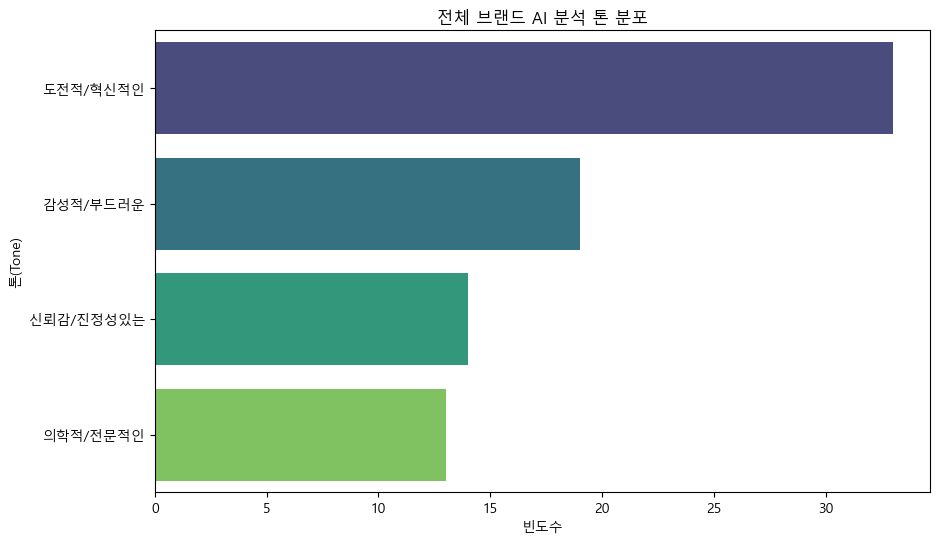

📌 [브랜드별 톤 분석 요약]
브랜드
AP        도전적/혁신적인
라네즈       도전적/혁신적인
라보에이치     도전적/혁신적인
려         도전적/혁신적인
롱테이크      감성적/부드러운
마몽드       도전적/혁신적인
메디안       의학적/전문적인
메이크온      도전적/혁신적인
미쟝센       도전적/혁신적인
바이탈뷰티     의학적/전문적인
비레디       감성적/부드러운
설화수       도전적/혁신적인
스킨유       감성적/부드러운
아윤채       감성적/부드러운
아이오페      도전적/혁신적인
에뛰드      신뢰감/진정성있는
에스쁘아      도전적/혁신적인
에스트라      의학적/전문적인
오딧세이      감성적/부드러운
오설록       감성적/부드러운
이니스프리     도전적/혁신적인
일리윤       감성적/부드러운
젠티스트      도전적/혁신적인
코스알엑스     감성적/부드러운
타타 하퍼    신뢰감/진정성있는
프리메라      의학적/전문적인
한율       신뢰감/진정성있는
해피바스      감성적/부드러운
헤라        도전적/혁신적인
홀리추얼      감성적/부드러운
Name: AI 분석 톤, dtype: object


📌 [톤별 평균 확신도 (AI Confidence)]
AI 분석 톤
감성적/부드러운     0.724211
도전적/혁신적인     0.696970
의학적/전문적인     0.650769
신뢰감/진정성있는    0.625714
Name: 확신도, dtype: float64


In [7]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 제공해주신 데이터 로드
csv_data = """브랜드,구분,내용 요약,핵심 키워드,AI 분석 톤,확신도,형용사 수
에스트라,Part 1,태평양제약에서 시작된 헤리티지에 기반해 오래도록 건강한...,"아름다움, 건강, 태평양, 제약, 시작",의학적/전문적인,0.32,1
에스트라,Part 2,에스트라가 의사를 만나는 이유     일시적 윤기와 잠...,"피부, 인증, 에스, 의료, 기기",의학적/전문적인,0.42,15
에스트라,Part 3,병원 밖으로 나온 더마 with 올리브영     에스트...,"병원, 시판, 고객, 라인, 화장품",도전적/혁신적인,0.50,7
AP,Part 1,$APEX OF SKINCARE TO UNVEIL BE...,"스킨케어, 한계, 경지, 정점, 아름다움",도전적/혁신적인,1.00,5
AP,Part 2,APEX OF SKINCARE     새로운 차원의 피...,"피부, 과학, 연구, 선도, 독자",도전적/혁신적인,0.96,4
아윤채,Part 1,Detailed & High Performing Sal...,"아윤채, 디자이너, 고객, 생각, 불편",감성적/부드러운,0.54,1
아윤채,Part 2,디자이너 살롱 워크를 위한 PRO와 데일리 헤어 라이프...,"헤어, 살롱, 워크, 데일리, 라이프",감성적/부드러운,0.56,1
비레디,Part 1,"Ordinary, but extraordinary     ...","자유, 센스, 남자, 취향, 레디",감성적/부드러운,0.89,4
비레디,Part 2,더 세련된 방식으로 나를 표현하도록 도와주는     각...,"자신, 표현, 스타일링, 세련, 방식",감성적/부드러운,0.88,2
비레디,Part 3,중요한 순간에 준비된 나를 만들어주는     나의 스타...,"중요, 순간, 준비, 스타일, 무드",신뢰감/진정성있는,0.67,0
코스알엑스,Part 1,"오직 성분으로, 오직 코스알엑스     ""Cosmeti...","성분, 화장품, 코스, 알, 엑스",신뢰감/진정성있는,0.77,3
코스알엑스,Part 2,미스터 알엑스는 오랜시간 동안 일상 속 뷰티 라이프 스...,"알, 엑스, 미스터, 뷰티, 코스",감성적/부드러운,0.56,4
코스알엑스,Part 3,brand concept Soft Skin Care  ...,"자극, 피부, 민감, 스킨케어, 친화",감성적/부드러운,0.96,1
에스쁘아,Part 1,자신만의 룩을 찾을 수 있도록 영감을 주는 Makeup...,"메이크업, 자신, 룩, 수, 영감",도전적/혁신적인,0.80,1
에스쁘아,Part 2,Detailed by Professionals     ...","컬러, 쉐이드, 디테일, 크리, 에이",도전적/혁신적인,0.48,0
에스쁘아,Part 3,BEAUTY CREATED     BY DETAILS....,,신뢰감/진정성있는,0.55,0
에뛰드,Part 1,Make Your Makeup Playlist! ETU...,"메이크업, 에뛰드, 문화, 경험, 전파",도전적/혁신적인,0.43,5
에뛰드,Part 2,color 라이프 스타일의 다채로움     Pink 유...,"스타일, 연습곡, 변화, 수, 라이프",신뢰감/진정성있는,0.58,7
에뛰드,Part 3,"Loved Products     자타공인, 역대 가장...","마스카라, 연속, 위, 기준, 컬링",신뢰감/진정성있는,0.95,1
젠티스트,Part 1,구강 고민에 독창적인 솔루션을 제공하는 덴탈케어 브랜드...,"고민, 독창, 데, 탈, 케어",도전적/혁신적인,0.99,1
젠티스트,Part 2,아모레퍼시픽의 전문적이고 체계적인 41년 구강 연구 노...,"구강, 아모레퍼시픽, 전문, 체계, 년",의학적/전문적인,0.94,1
한율,Part 1,나만의 건강한 균형     Everyday glass ...,"피부, 건강, 한국, 여성, 마음",감성적/부드러운,0.72,2
한율,Part 2,"한국의 이로움으로 전하는 균형 잡힌 아름다움, 한율  ...","수, 한국, 로컬, 극대, 효과",신뢰감/진정성있는,0.54,10
한율,Part 3,"피부 스스로 강해질 수 있는 힘,     마이크로바이옴...","과학, 피부, 균형, 한국, 발효",신뢰감/진정성있는,0.77,11
해피바스,Part 1,일상에 행복을 더하는 향과 건강한 원료를 담은     ...,"향, 행복, 브랜드, 일상, 년",감성적/부드러운,0.81,3
해피바스,Part 2,"온가족이 함께 쓰는 바디클렌저, 안전한 원료와 믿을 수...","고객, 바디, 가족, 클렌저, 안전",신뢰감/진정성있는,0.97,3
헤라,Part 1,Contemporary Seoul Beauty     ...,"서울, 자신, 헤라, 아름다움, 해석",도전적/혁신적인,0.63,9
헤라,Part 2,SENSUAL POWDER MATTE LIQUID   ...,,감성적/부드러운,0.76,0
헤라,Part 3,CONTEMPORARY     SEOUL BEAUTY ...,"서울, 자신, 헤라, 아름다움, 해석",도전적/혁신적인,0.70,9
홀리추얼,Part 1,Holistic Rituals for Skin Well...,"전문가, 얼, 혁신, 기술, 에스테틱",의학적/전문적인,0.85,1
홀리추얼,Part 2,우리는 거울 앞 무의미하게 반복되는 당신의 스킨케어 루...,"자신, 얼, 감각, 추, 거울",감성적/부드러운,0.59,0
일리윤,Part 1,Amorepacific     민감한 피부 고민에 대한...,"피부, 연구, 민감, 수, 리",감성적/부드러운,0.83,25
일리윤,Part 2,"INTERVIEW 01     모윤희     (17, ...","피부, 윤, 리, 수, 세라마이드",감성적/부드러운,0.40,29
일리윤,Part 3,주요성분     3가지 핵심성분     피토 세라마이드...,"피부, 세라마이드, 보습, 케어, 경험",도전적/혁신적인,0.39,18
이니스프리,Part 1,"Effective, Nature-Powered Skin...","무한, 에너지, 자연, 탐구, 아름다움",도전적/혁신적인,0.87,2
이니스프리,Part 2,the Origin of INNISFREE     천혜...,"녹차, 수, 피부, 이니스프리, 년",도전적/혁신적인,0.94,4
이니스프리,Part 3,with INNISFREE     Better for ...,"제품, 환경, 이니스프리, 보전, 제주",도전적/혁신적인,0.41,5
아이오페,Part 1,클리니컬 레벨 테크(Clinical Level Tech...,"효능, 변화, 피부, 클리니컬, 레벨",신뢰감/진정성있는,0.62,3
아이오페,Part 2,IOPE LAB     아이오페 랩은 브랜드의 오리진으...,"피부, 연구, 기술, 아이오페, 미래",도전적/혁신적인,0.99,2
아이오페,Part 3,ESSENCE & BENEFIT     피부미래연구소 ...,"고객, 솔루션, 이노베이터, 직접, 만남",의학적/전문적인,0.74,4
라보에이치,Part 1,두피 스킨케어 전문가_라보에이치     아모레퍼시픽 피...,"두피, 라보, 근본, 솔루션, 스킨케어",의학적/전문적인,0.66,1
라보에이치,Part 2,LABOratory Of Honesty     진심을 ...,"두피, 연구, 피부, 진심, 연구소",신뢰감/진정성있는,0.76,1
라보에이치,Part 3,스칼프베리어218™     라보에이치가 선택한 단 하나...,"스칼프베리어, 선택, 성분, 기술, 프로바이오틱스",도전적/혁신적인,0.48,1
라네즈,Part 1,아름다움을 향한 끝없는 호기심     OPEN TO W...,"호기심, 힘, 만약, 시작, 가능",도전적/혁신적인,0.97,24
라네즈,Part 2,THE CORE PRODUCT PILLARS     H...,"피부, 수분, 보습, 기술, 라네즈",도전적/혁신적인,0.71,5
라네즈,Part 3,SLEEPING BEAUTY TECHNOLOGY    ...,"제품, 피부, 수, 스킨케어, 제공",도전적/혁신적인,0.63,7
롱테이크,Part 1,깊은 숲에서 영감을 받은 감성향 지속가능 브랜드     ...,"지속, 가능, 브랜드, 감, 성향",감성적/부드러운,0.85,1
롱테이크,Part 2,사람의 발길이 닿지 않은 깊은 숲에서 영감을 받은 감각...,"사람, 발길, 편안, 우디, 일상",감성적/부드러운,0.99,2
메이크온,Part 1,"피부를 잘 아는 뷰티 디바이스, 메이크온     메이크...","뷰티, 디바이스, 메이크, 아, 열망",도전적/혁신적인,0.68,2
메이크온,Part 2,"메이크온은 빛(Light), 열(Heat), 이온(Io...","빛, 열, 이온, 진동, 포함",도전적/혁신적인,0.98,2
메이크온,Part 3,"쏟아져 나오는 뷰티 디바이스 제품들 사이에서, 메이크온...","뷰티, 스킨케어, 제품, 사이, 필요",신뢰감/진정성있는,0.39,1
마몽드,Part 1,Hyper Flora™로 피어나는 나다운 아름다움   ...,"성분, 꽃, 로, 부스팅, 스킨",도전적/혁신적인,0.89,4
마몽드,Part 2,Powered by Hyper Flora     하이퍼...,"스킨케어, 성분, 하이퍼, 플로라, 최신",도전적/혁신적인,0.55,1
마몽드,Part 3,자신만의 독특한 방식으로     삶을 꽃 피울 수 있도...,"꽃, 자신, 독특, 방식, 삶",도전적/혁신적인,0.54,3
메디안,Part 1,내 치아를 위한 맞춤 처방     메디안은 “건강한 치...,"치아, 건강, 년, 기능, 구강",의학적/전문적인,0.67,2
메디안,Part 2,많은 고객에게 사랑을 받은 치석 전문 ‘치석케어 93%...,"치약, 고객, 사랑, 치석, 고민",의학적/전문적인,0.81,3
미쟝센,Part 1,SHINE YOUR SCENE     글로벌 헤어패션 ...,"헤어, 글로벌, 패션, 브랜드, 미쟝센",도전적/혁신적인,0.55,1
미쟝센,Part 2,"CHANGE YOUR HAIR, CHANGE YOUR ...","미쟝센, 디렉터, 은, 화면, 배치",도전적/혁신적인,0.60,1
미쟝센,Part 3,"미쟝센을 만나는 순간,     모든 곳이 무대     ...","스타일, 일상, 무대, 순간, 것",도전적/혁신적인,0.89,3
오딧세이,Part 1,매력적인 남성미와 미향(美香)을 향한 여정     오딧...,"남성, 매력, 남성미, 여정, 향",도전적/혁신적인,0.80,2
오딧세이,Part 2,25년이 넘는 남성 헤리티지의 오딧세이는 앞으로도 세련...,"남성, 헤리티지, 앞, 세련, 아이덴티티",감성적/부드러운,0.43,0
오설록,Part 1,Tea from Jeju Island     “어느 나...,"차, 제주, 나라, 바람, 수",신뢰감/진정성있는,0.39,14
오설록,Part 2,오설록의 제주 차밭     약 100만 평에 달하는 3...,"차, 밭, 송이, 돌, 설",감성적/부드러운,0.61,12
오설록,Part 3,자연을 숨쉬게 하는 차밭     자연을 지키는 유기농 ...,"차, 제주, 량, 발효, 사람",감성적/부드러운,0.46,3
프리메라,Part 1,All about skin barrier by SEED...,"장벽, 피부, 씨드, 테크, 기반",도전적/혁신적인,0.51,2
프리메라,Part 2,Powerful Result Mixology Recip...,"피부, 여성, 고민, 자극, 이상",의학적/전문적인,0.38,1
프리메라,Part 3,Powerful Result Mixology Recip...,"등, 효능, 조합, 개선, 스킨케어",의학적/전문적인,0.44,1
려,Part 1,뿌리로부터 자라는 본연의 아름다움     뿌리깊은 나무...,"뿌리, 본연, 나무, 곳, 근본",의학적/전문적인,0.36,4
려,Part 2,2008년에 런칭한 ‘려’는 1973년부터 시작된 아모...,"년, 제품, 시작, 아모레퍼시픽, 연구",도전적/혁신적인,0.51,0
려,Part 3,최근 려는 원인과 증상이 다른 남녀의 탈모를 맞춤 케어...,"케어, 탈모, 최근, 원인, 증상",도전적/혁신적인,0.91,2
스킨유,Part 1,내 몸의 감각을 일깨우는 섬세한 바디케어 브랜드 스킨유...,"감각, 바디, 케어, 스킨, 유",감성적/부드러운,0.99,1
스킨유,Part 2,머스크향이 나는 자연의 열매인 암브레트 씨드를 향에 담...,"향, 피부, 머스크, 자연, 열매",감성적/부드러운,0.93,3
설화수,Part 1,시간의 흐름에 지지 않는 아름다움     Journey...,"시선, 본질, 시간, 흐름, 홀리",도전적/혁신적인,0.79,8
설화수,Part 2,"집념의 60년 연구,     피부 장수를 위한 인삼  ...","인삼, 단, 원료, 수, 자음",도전적/혁신적인,0.47,5
설화수,Part 3,설화수가 만드는     윤빛 도는 힘 있는 피부    ...,"피부, 노화, 자생력, 자극, 크림",도전적/혁신적인,0.45,1
타타 하퍼,Part 1,High-Performance Natural Skinc...,"타, 내추럴, 뷰티, 선구자, 년",신뢰감/진정성있는,0.48,0
타타 하퍼,Part 2,타타 하퍼 농장에서 발견하는 자연의 이치와 과학을 토대...,"자연, 최고, 타타, 농장, 발견",신뢰감/진정성있는,0.32,0
바이탈뷰티,Part 1,VITALBEAUTIE     과학적 설계로 완성한 건...,"과학, 식품, 생명, 완성, 뷰티",의학적/전문적인,0.88,1
바이탈뷰티,Part 2,"바이탈뷰티 랩은 영양 대사, 면역, 의약학, 이너뷰티 ...","웰니스, 효능, 대사, 면역, 이너뷰티",의학적/전문적인,0.99,1
"""

# 데이터프레임으로 변환
df = pd.read_csv(io.StringIO(csv_data))

# 2. 브랜드별 톤 요약 (가장 빈번하게 나온 톤 확인)
brand_tone_summary = df.groupby(['브랜드', 'AI 분석 톤']).size().unstack(fill_value=0)

# 3. 톤 분포 시각화
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows (Mac은 'AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
sns.countplot(y='AI 분석 톤', data=df, order=df['AI 분석 톤'].value_counts().index, palette='viridis')
plt.title('전체 브랜드 AI 분석 톤 분포')
plt.xlabel('빈도수')
plt.ylabel('톤(Tone)')
plt.show()

# 4. 결과 출력
print("="*60)
print("📌 [브랜드별 톤 분석 요약]")
print("="*60)
# 각 브랜드별로 가장 많이 나타난 톤 출력
dominant_tones = df.groupby('브랜드')['AI 분석 톤'].agg(lambda x: x.mode()[0])
print(dominant_tones)
print("\n")

print("📌 [톤별 평균 확신도 (AI Confidence)]")
print(df.groupby('AI 분석 톤')['확신도'].mean().sort_values(ascending=False))

In [6]:
%pip install matplotlib seaborn

     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ---------------------------------------- 52.8/52.8 kB 1.4 MB/s eta 0:00:00
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/116.4 kB ? eta -:--:--
     -------------------------------------- 116.4/116.4 kB 3.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 16.8 MB/s eta 0:00:01
   -------- ------------------------------- 1.7/8.1 MB 21.9 MB/s eta 0:00:01
   ---------- ----------------------------- 2.2/8.1 MB 20.0 MB/s eta 0:00:01
   ---------------- ----------------------- 3.3/8.1 MB 19.2 MB/s eta 0:00:01
   --------------------- ------------------ 4.4/8.1 MB 20.2 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 20.7 MB/s eta 0:00:01
   --------------------------------


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
